In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
import warnings, os
import datetime
from scipy import stats
from sklearn.preprocessing import MinMaxScaler

A. EDA FOR BOOKS

In [ ]:
books = pd.read_csv("/content/6000_bookssamples.csv")
books.head()

,book_id,author,desc,genre,isbn,isbn13,link,pages,rating,reviews,title,totalratings,title_clean,author_clean,bookformat_clean,genre_clean,desc_clean,word_count
0,20385,"Victor Skrebneski,Victor Skrebneski",Illustrated with Victor Skrebneski's closeups ...,"Couture,Fashion,Art",789200228,9.78079E+12,https://goodreads.com/book/show/1455361.The_Ar...,175.0,4.14,0,The Art of Haute Couture,7,the art of haute couture,"victor skrebneski,victor skrebneski",Hardcover,couture|fashion|art,illustrated with victor skrebneski s closeups ...,128
1,17418,Martin A. Miller,Why is it that terrorism has become such a cen...,"War,Terrorism",113960385X,9.78114E+12,https://goodreads.com/book/show/17137531-the-f...,270.0,3.76,1,"The Foundations of Modern Terrorism: State, So...",17,"the foundations of modern terrorism: state, so...",martin a. miller,Ebook,war|terrorism,why is it that terrorism has become such a cen...,150
2,3525,Pamela A. Sambrook,"Until the eighteenth century or even later, be...","Alcohol,Beer,History",1852851279,9.78185E+12,https://goodreads.com/book/show/1714952.Countr...,332.0,4.00,0,"Country House Brewing in England, 1500-1900",7,"country house brewing in england, 1500-1900",pamela a. sambrook,Hardcover,alcohol|beer|history,until the eighteenth century or even later bee...,276
3,6740,Linda L. Ernst,"This innovative, comprehensive resource will h...","Science,Library Science",1555707610,9.78156E+12,https://goodreads.com/book/show/14431761-the-e...,276.0,3.67,0,The Essential Lapsit Guide an Multimedia How-T...,3,the essential lapsit guide an multimedia how-t...,linda l. ernst,Paperback,science|library science,this innovative comprehensive resource will he...,204
4,4745,Alan Bjerga,How to understand the twenty-first century foo...,"Food and Drink,Food",1118043235,9.78E+12,https://goodreads.com/book/show/12898732-endle...,196.0,3.75,4,Endless Appetites: How the Commodities Casino ...,20,endless appetites: how the commodities casino ...,alan bjerga,Hardcover,food and drink|food,how to understand the twenty first century foo...,259


In [ ]:
# Check column names
books.columns

Index(['book_id', 'author', 'desc', 'genre', 'isbn', 'isbn13', 'link', 'pages',
       'rating', 'reviews', 'title', 'totalratings', 'title_clean',
       'author_clean', 'bookformat_clean', 'genre_clean', 'desc_clean',
       'word_count'],
      dtype='object')

NOTE: Features explanation

rating: Average rating of the book

reviews: The number of reviews the book has

totalratings: Totalratings of the book

In [ ]:
# Find number of samples and features
books.shape

(6000, 18)

In [ ]:
# Check data types of features
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   book_id           6000 non-null   int64  
 1   author            6000 non-null   object 
 2   desc              6000 non-null   object 
 3   genre             6000 non-null   object 
 4   isbn              5504 non-null   object 
 5   isbn13            5598 non-null   object 
 6   link              6000 non-null   object 
 7   pages             5619 non-null   float64
 8   rating            6000 non-null   float64
 9   reviews           6000 non-null   int64  
 10  title             6000 non-null   object 
 11  totalratings      6000 non-null   int64  
 12  title_clean       6000 non-null   object 
 13  author_clean      6000 non-null   object 
 14  bookformat_clean  6000 non-null   object 
 15  genre_clean       6000 non-null   object 
 16  desc_clean        6000 non-null   object 


In [ ]:
# Only keep columns we need
important_columns = ['book_id', 'title', 'author', 'genre_clean', 'desc_clean', 'rating', 'reviews', 'totalratings', 'isbn', 'isbn13', 'link'].copy()

In [ ]:
def plot_books_by(df, col, n_rows=10):
    plt.figure(figsize=(12,7))
    ax = sns.barplot(x=df[col].head(n_rows), y=df['title'].head(n_rows), data=df)
    plt.title('Best ' + str(n_rows) + ' books by ' + col.replace('_',' ').capitalize(), weight='bold')
    plt.xlabel('Score of ' + col)
    plt.ylabel('Book Title')

In [ ]:
# Remove 10 books with rating = 0 (no rating data — would skew all analyses)
books = books[books["rating"] > 0].copy()
books["tag_count"] = books["genre_clean"].str.split("|").apply(len)
books["desc_len"]  = books["desc"].str.len()

print(f"Loaded: {len(books):,} books (removed {6000-len(books)} with rating=0)")
print(f"Columns: {books.columns.tolist()}\n")

Loaded: 5,990 books (removed 10 with rating=0)
Columns: ['book_id', 'author', 'desc', 'genre', 'isbn', 'isbn13', 'link', 'pages', 'rating', 'reviews', 'title', 'totalratings', 'title_clean', 'author_clean', 'bookformat_clean', 'genre_clean', 'desc_clean', 'word_count', 'tag_count', 'desc_len']



In [ ]:
C = {
    "brown":  "#5C3D1E", "gold":   "#C4913A",
    "sage":   "#7A8C6E", "terra":  "#B05E3F",
    "cream":  "#F7F3EC", "muted":  "#8B6B47",
    "purple": "#6B5A8E", "teal":   "#3A7068",
     "navy": "#1f4e79",
}
SENT_PAL = {"positive": C["sage"], "neutral": C["gold"], "negative": C["terra"]}

sns.set_theme(style="whitegrid", font="serif")
plt.rcParams.update({
    "figure.facecolor": C["cream"], "axes.facecolor": C["cream"],
    "axes.edgecolor":   C["muted"], "axes.titlesize":  13,
    "axes.labelsize":   11,         "grid.color":      "#E8DFD0",
    "grid.linewidth":   0.6,        "axes.titleweight": "bold",
    "axes.titlecolor":  C["brown"],
})

def save(name):
    plt.savefig(f"nlp_figures/{name}.png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  → saved nlp_figures/{name}.png")

def bar_label(ax, values, fmt="{:.2f}", offset=0.005, fontsize=9):
    for i, v in enumerate(values):
        ax.text(i, v + offset, fmt.format(v),
                ha="center", fontsize=fontsize, color=C["brown"])

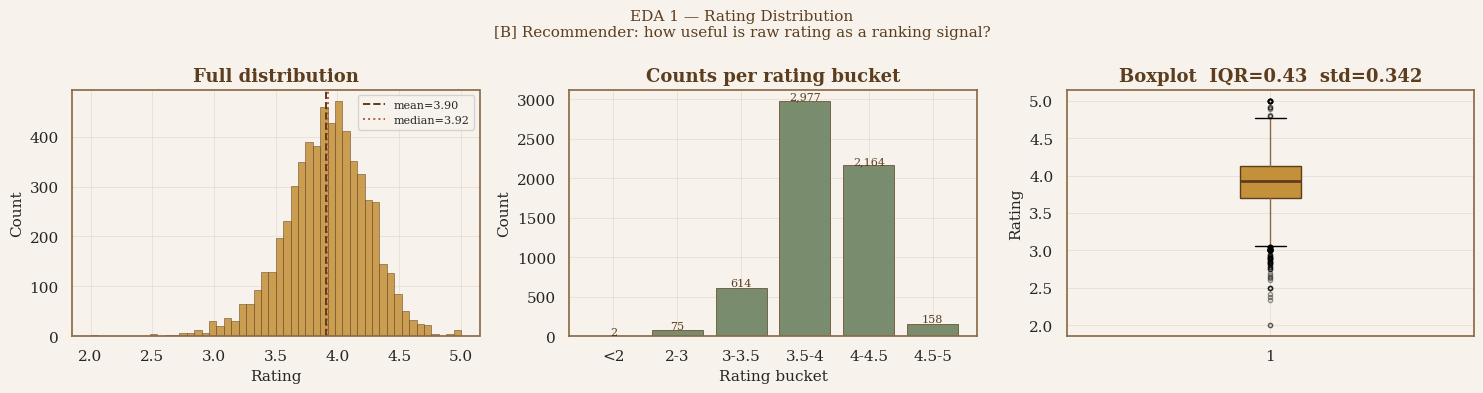

In [ ]:
# EDA 1: Rating distribution

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(
    "EDA 1 — Rating Distribution\n"
    "[B] Recommender: how useful is raw rating as a ranking signal?",
    fontsize=11, color=C["brown"]
)

# 1a — full histogram
axes[0].hist(books["rating"], bins=50, color=C["gold"],
             edgecolor=C["brown"], linewidth=0.4, alpha=0.88)
axes[0].axvline(books["rating"].mean(),   color=C["brown"],  linestyle="--",
                linewidth=1.4, label=f"mean={books['rating'].mean():.2f}")
axes[0].axvline(books["rating"].median(), color=C["terra"],  linestyle=":",
                linewidth=1.4, label=f"median={books['rating'].median():.2f}")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")
axes[0].set_title("Full distribution")
axes[0].legend(fontsize=8)

# 1b — binned bar
bins_r   = [0, 2, 3, 3.5, 4, 4.5, 5]
labels_r = ["<2","2-3","3-3.5","3.5-4","4-4.5","4.5-5"]
books["rating_bin"] = pd.cut(books["rating"], bins=bins_r, labels=labels_r)
rb = books["rating_bin"].value_counts().sort_index()
axes[1].bar(rb.index, rb.values, color=C["sage"],
            edgecolor=C["brown"], linewidth=0.5)
axes[1].set_xlabel("Rating bucket")
axes[1].set_ylabel("Count")
axes[1].set_title("Counts per rating bucket")
for i, v in enumerate(rb.values):
    axes[1].text(i, v+20, f"{v:,}", ha="center", fontsize=8, color=C["brown"])

# 1c — box + IQR annotation
axes[2].boxplot(books["rating"], vert=True, patch_artist=True,
                boxprops=dict(facecolor=C["gold"], color=C["brown"]),
                medianprops=dict(color=C["brown"], linewidth=2),
                whiskerprops=dict(color=C["muted"]),
                flierprops=dict(marker="o", color=C["terra"],
                                markersize=3, alpha=0.4))
q1  = books["rating"].quantile(0.25)
q3  = books["rating"].quantile(0.75)
iqr = q3 - q1
axes[2].set_title(f"Boxplot  IQR={iqr:.2f}  std={books['rating'].std():.3f}")
axes[2].set_ylabel("Rating")

for ax in axes:
    ax.set_facecolor(C["cream"])
plt.tight_layout()

- 86% of books sit between 3.5–4.5. IQR = 0.43, std = 0.342
- This is extremely compressed — ranking the top-100 candidates
    by raw rating alone produces nearly indistinguishable scores.
- The recommender MUST combine rating with other signals
    (totalratings, reviews, NLP liked_ratio) to produce meaningful ranks
    
=> Never use raw rating as a sole ranking signal.
    Use it as one weighted component in a composite score

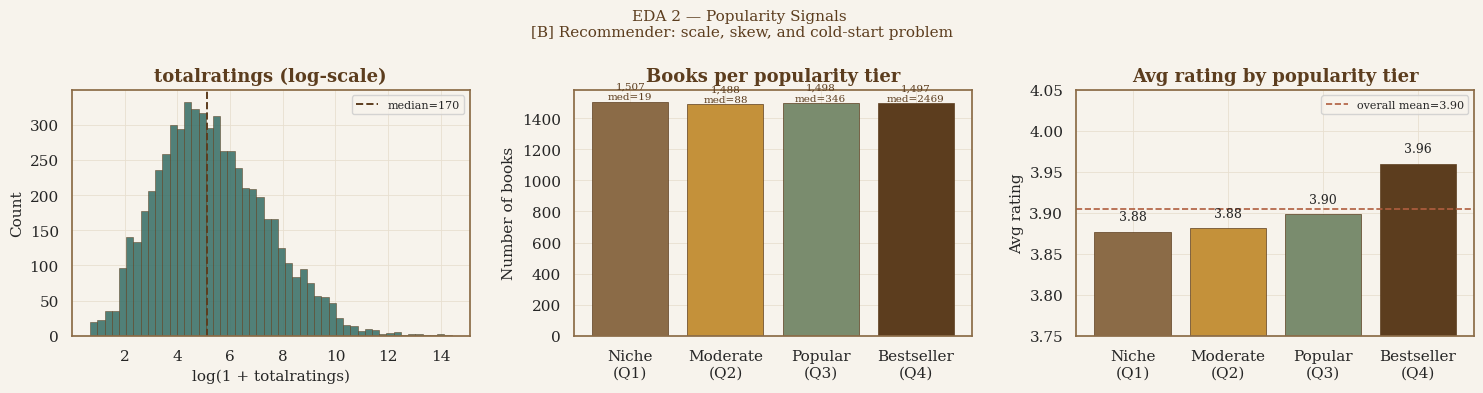

In [ ]:
# EDA 2: Popularity signals (totalratings & reviews) ───────────")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(
    "EDA 2 — Popularity Signals \n"
    "[B] Recommender: scale, skew, and cold-start problem",
    fontsize=11, color=C["brown"]
)

# 2a — totalratings log-scale histogram
axes[0].hist(np.log1p(books["totalratings"]), bins=50,
             color=C["teal"], edgecolor=C["brown"], linewidth=0.4, alpha=0.88)
axes[0].set_xlabel("log(1 + totalratings)")
axes[0].set_ylabel("Count")
axes[0].set_title("totalratings (log-scale)")
axes[0].axvline(np.log1p(books["totalratings"].median()), color=C["brown"],
                linestyle="--", linewidth=1.4,
                label=f"median={books['totalratings'].median():.0f}")
axes[0].legend(fontsize=8)

# 2b — tier bar (niche / moderate / popular / bestseller)
tier_labels = ["Niche\n(Q1)","Moderate\n(Q2)","Popular\n(Q3)","Bestseller\n(Q4)"]
books["pop_tier"] = pd.qcut(books["totalratings"], q=4, labels=tier_labels)
tier_counts = books["pop_tier"].value_counts().sort_index()
tier_medians = books.groupby("pop_tier", observed=True)["totalratings"].median()
bars = axes[1].bar(tier_labels, tier_counts.values,
                   color=[C["muted"],C["gold"],C["sage"],C["brown"]],
                   edgecolor=C["brown"], linewidth=0.5)
axes[1].set_ylabel("Number of books")
axes[1].set_title("Books per popularity tier")
for bar, cnt, med in zip(bars, tier_counts.values, tier_medians.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, cnt+15,
                 f"{cnt:,}\nmed={med:.0f}", ha="center", fontsize=7.5,
                 color=C["brown"])

# 2c — rating per tier
tier_rating = books.groupby("pop_tier", observed=True)["rating"].mean()
axes[2].bar(tier_labels, tier_rating.values,
            color=[C["muted"],C["gold"],C["sage"],C["brown"]],
            edgecolor=C["brown"], linewidth=0.5)
axes[2].axhline(books["rating"].mean(), color=C["terra"], linestyle="--",
                linewidth=1.2, label=f"overall mean={books['rating'].mean():.2f}")
axes[2].set_ylabel("Avg rating")
axes[2].set_title("Avg rating by popularity tier")
axes[2].set_ylim(3.75, 4.05)
axes[2].legend(fontsize=8)
def annotate_bars_v(ax, values):
    for i, v in enumerate(values):
        ax.text(i, v + 0.01, f"{v:.2f}",
                ha='center', va='bottom', fontsize=9)
annotate_bars_v(axes[2], tier_rating.values)

for ax in axes:
    ax.set_facecolor(C["cream"])
plt.tight_layout()

- Total ratings is right-skewed: median = 170 => long-tail distribution
- Books were evenly distributed across popularity tiers using quartile-based segmentation => fair segmentation help to fairly compair behavior of users
- Bestseller books rate higher (≈3.96) than niche books (≈3.87),
    but the gap is small — niche books are quality-competitive
- Niche books (25%) fewer ratings
    the cold-start zone where collaborative signals are unreliable
- Many niche books with fewer ratings may contain specialized tropes that are underrepresented in recommendation systems due to their lower popularity

=> In the recommender, apply log(1+totalratings) as a small-weight
    confidence boost, not a quality proxy. Niche books that match
    a trope query should still surface alongside blockbusters.

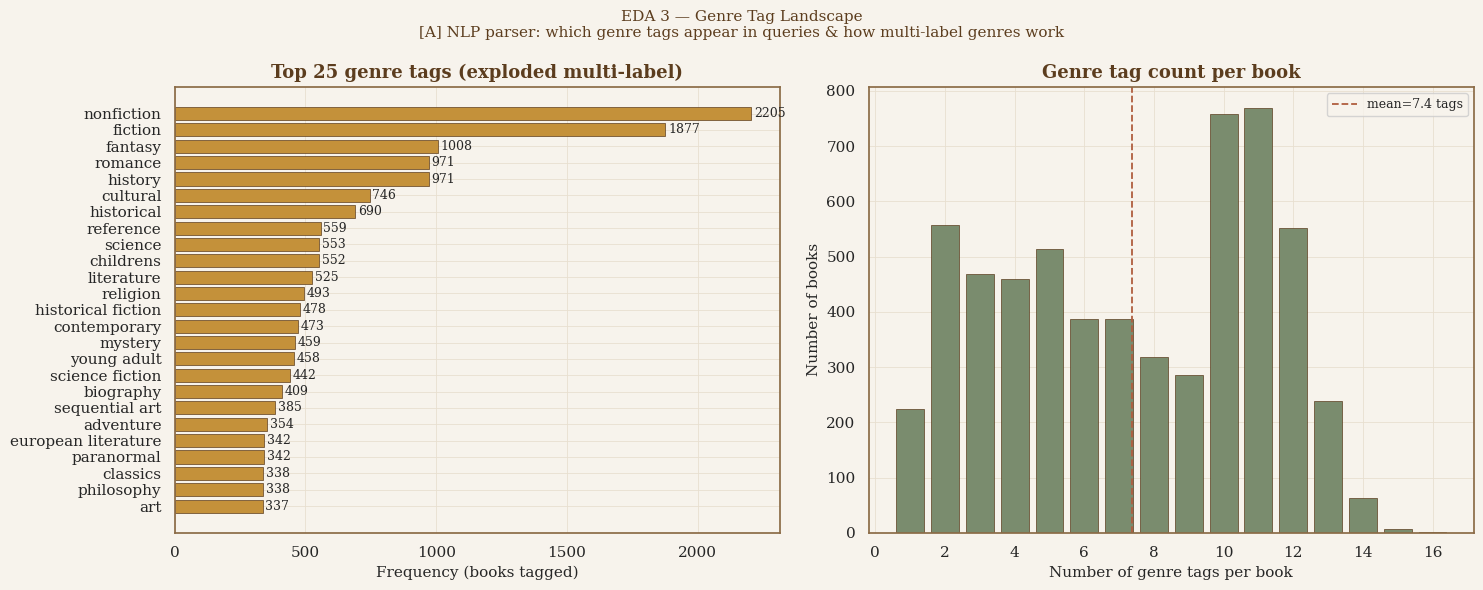

In [ ]:
# EDA 3: Genre tag landscape

exploded = books["genre_clean"].str.split("|").explode().str.strip()
genre_freq  = exploded.value_counts().head(25)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    "EDA 3 — Genre Tag Landscape\n"
    "[A] NLP parser: which genre tags appear in queries & how multi-label genres work",
    fontsize=11, color=C["brown"]
)

# 3a — top 25 genre tags
axes[0].barh(genre_freq.index[::-1], genre_freq.values[::-1],
             color=C["gold"], edgecolor=C["brown"], linewidth=0.5)
axes[0].set_xlabel("Frequency (books tagged)")
axes[0].set_title("Top 25 genre tags (exploded multi-label)")
def annotate_bars_h(ax, values, offset=5):
    for i, v in enumerate(values):
        ax.text(v + offset, i, f"{v:.0f}",
                va='center', fontsize=9)
annotate_bars_h(axes[0], genre_freq.values[::-1], offset=10)
axes[0].set_facecolor(C["cream"])

# 3b — tag count distribution
tag_dist = books["tag_count"].value_counts().sort_index()
axes[1].bar(tag_dist.index, tag_dist.values, color=C["sage"],
            edgecolor=C["brown"], linewidth=0.5)
axes[1].set_xlabel("Number of genre tags per book")
axes[1].set_ylabel("Number of books")
axes[1].set_title("Genre tag count per book")
axes[1].axvline(books["tag_count"].mean(), color=C["terra"], linestyle="--",
                linewidth=1.3, label=f"mean={books['tag_count'].mean():.1f} tags")
axes[1].legend(fontsize=9)
axes[1].set_facecolor(C["cream"])

plt.tight_layout()

- Books carry 1–16 genre tags (mean= 7.4) — richly multi-labelled.
- nonfiction (2,205) + fiction (1,877) dominate, but the long tail of
    sub-genres (paranormal, historical fiction, sequential art) is where
    trope-based discovery has the most differentiation power.
- Genre tags are pipe-separated: "fantasy|romance|paranormal" is ONE book.
    A query for "paranormal romance" should match books containing BOTH tags => Gerne tags combination may carry tropes
- Many overlapping subgenres: history, historical, historical fiction => Genre tags include both broad categories and highly specific subgenres



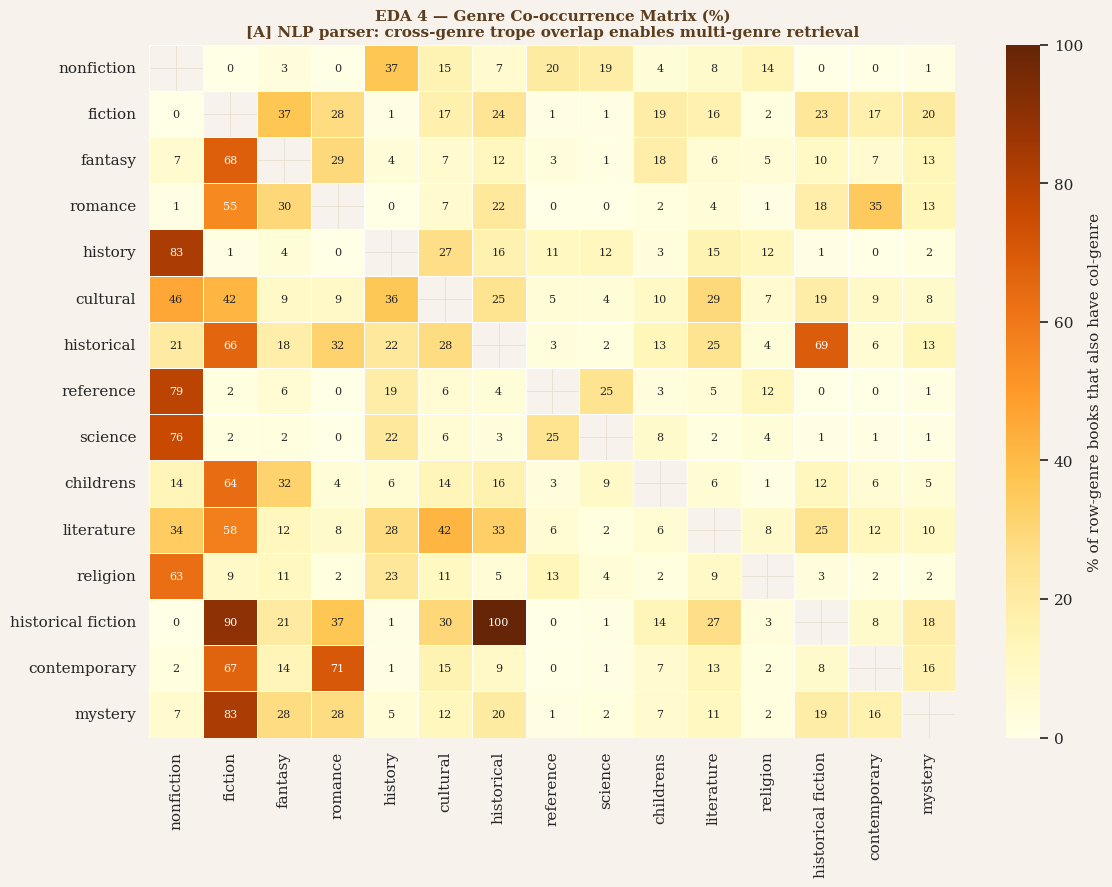

In [ ]:
# EDA 4: Genre co-occurrence

# Build co-occurrence matrix for top 15 genres
TOP15 = genre_freq.head(15).index.tolist()
cooc  = pd.DataFrame(0, index=TOP15, columns=TOP15)
for tags in books["genre_clean"].str.split("|"):
    tags = [t.strip() for t in tags if t.strip() in TOP15]
    for i, a in enumerate(tags):
        for b in tags[i:]:
            cooc.loc[a, b] += 1
            if a != b:
                cooc.loc[b, a] += 1

# Normalise: % of books with tag A that also have tag B
cooc_pct = cooc.copy().astype(float)
for g in TOP15:
    total = cooc.loc[g, g]
    if total > 0:
        cooc_pct.loc[g] = cooc.loc[g] / total * 100
cooc_pct_arr = cooc_pct.values.copy()
np.fill_diagonal(cooc_pct_arr, np.nan)
cooc_pct = pd.DataFrame(cooc_pct_arr, index=cooc_pct.index, columns=cooc_pct.columns)

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(cooc_pct.round(0), cmap="YlOrBr", ax=ax, annot=True,
            fmt=".0f", linewidths=0.4, annot_kws={"size": 8},
            cbar_kws={"label": "% of row-genre books that also have col-genre"})
ax.set_title(
    "EDA 4 — Genre Co-occurrence Matrix (%)\n"
    "[A] NLP parser: cross-genre trope overlap enables multi-genre retrieval",
    fontsize=11, color=C["brown"], fontweight="bold"
)
ax.set_facecolor(C["cream"])

- fantasy ↔ romance:  30% of fantasy books also carry romance tag.
    "enemies-to-lovers" query should retrieve from BOTH genres.
- fantasy ↔ paranormal: 32% overlap — paranormal romance and
    fantasy share significant trope vocabulary (vampires, magic, fae).
- historical ↔ romance:  23% — "historical romance" is a well-defined
    cross-genre cluster; treat it as a single retrieval bucket.
- nonfiction and fiction rarely co-occur (<5%) — they are the two
    top-level separators; query intent usually falls clearly in one.

=> The co-occurrence matrix becomes a genre expansion table:
    when query intent maps to genre G, also retrieve from genres
    that share >20% with G to widen the candidate pool before
    the semantic re-ranker narrows it back down.

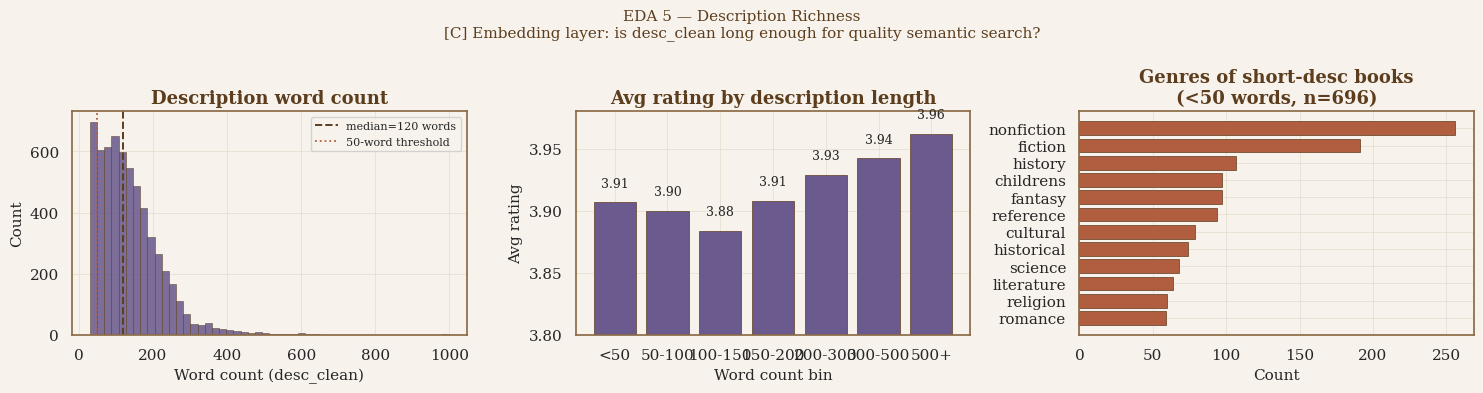

In [ ]:
# EDA 5: Description richness

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(
    "EDA 5 — Description Richness\n"
    "[C] Embedding layer: is desc_clean long enough for quality semantic search?",
    fontsize=11, color=C["brown"]
)

# 5a — word_count histogram
axes[0].hist(books["word_count"], bins=50, color=C["purple"],
             edgecolor=C["brown"], linewidth=0.4, alpha=0.88)
axes[0].axvline(books["word_count"].median(), color=C["brown"], linestyle="--",
                linewidth=1.4, label=f"median={books['word_count'].median():.0f} words")
axes[0].axvline(50, color=C["terra"], linestyle=":", linewidth=1.3,
                label="50-word threshold")
axes[0].set_xlabel("Word count (desc_clean)")
axes[0].set_ylabel("Count")
axes[0].set_title("Description word count")
axes[0].legend(fontsize=8)

# 5b — word count bins vs avg rating
bins_w  = [0,50,100,150,200,300,500,999]
labs_w  = ["<50","50-100","100-150","150-200","200-300","300-500","500+"]
books["wc_bin"] = pd.cut(books["word_count"], bins=bins_w, labels=labs_w)
wc_stats = books.groupby("wc_bin", observed=True).agg(
    n=("rating","count"), avg_rating=("rating","mean"),
    avg_pop=("totalratings","median")
).round(3)
axes[1].bar(wc_stats.index, wc_stats["avg_rating"],
            color=C["purple"], edgecolor=C["brown"], linewidth=0.5)
axes[1].set_xlabel("Word count bin")
axes[1].set_ylabel("Avg rating")
axes[1].set_title("Avg rating by description length")
axes[1].set_ylim(3.80, 3.98)
annotate_bars_v(axes[1], wc_stats["avg_rating"].values)
axes[1].set_facecolor(C["cream"])

# 5c — books below 50 words: breakdown by genre
short_desc = books[books["word_count"] < 50]
short_genre = short_desc["genre_clean"].str.split("|").explode().str.strip()
sg_counts   = short_genre.value_counts().head(12)
axes[2].barh(sg_counts.index[::-1], sg_counts.values[::-1],
             color=C["terra"], edgecolor=C["brown"], linewidth=0.5)
axes[2].set_xlabel("Count")
axes[2].set_title(f"Genres of short-desc books\n(<50 words, n={len(short_desc)})")
axes[2].set_facecolor(C["cream"])

for ax in [axes[0], axes[1]]:
    ax.set_facecolor(C["cream"])
plt.tight_layout()

- Median description = 120 words. Most fall in the
    50–200 word range — short but embeddable with sentence-transformers
- Avg rating rises slightly with description length (3.88 → 3.94 for
    300-500 words) => better-described books attract more engaged readers. May it contain more special keyword trope in that?

                  n  avg_rating  med_ratings
page_bin                                    
<100\n(short)   657       3.846        174.0
100-200        1249       3.871        149.0
200-300        1607       3.877        171.0
300-400        1179       3.914        295.0
400-600         647       3.996        212.0
600+\n(epic)    267       4.106        187.0


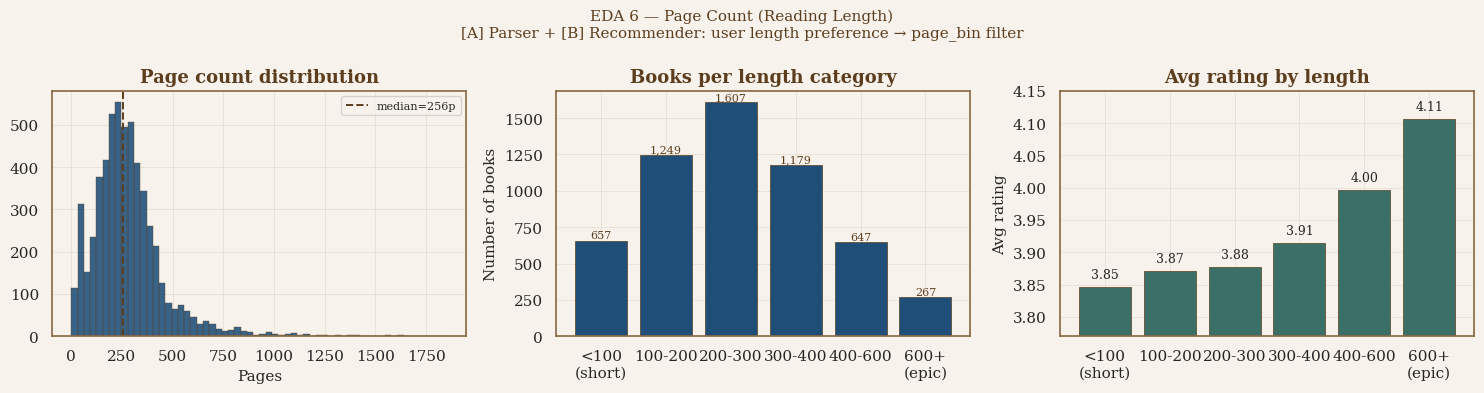

In [ ]:
# EDA 6: Page count as reading length preference

books_p = books.dropna(subset=["pages"]).copy()
books_p = books_p[books_p["pages"].between(1, 2000)]   # remove outliers (70k pages)

bins_p  = [0,100,200,300,400,600,2000]
labs_p  = ["<100\n(short)","100-200","200-300","300-400","400-600","600+\n(epic)"]
books_p["page_bin"] = pd.cut(books_p["pages"], bins=bins_p, labels=labs_p)
pg_stats = books_p.groupby("page_bin", observed=True).agg(
    n=("book_id","count"), avg_rating=("rating","mean"),
    med_ratings=("totalratings","median"),
).round(3)
print(pg_stats.to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(
    "EDA 6 — Page Count (Reading Length)\n"
    "[A] Parser + [B] Recommender: user length preference → page_bin filter",
    fontsize=11, color=C["brown"]
)

axes[0].hist(books_p["pages"], bins=60, color=C["navy"],
             edgecolor=C["brown"], linewidth=0.3, alpha=0.88)
axes[0].axvline(books_p["pages"].median(), color=C["brown"], linestyle="--",
                linewidth=1.4, label=f"median={books_p['pages'].median():.0f}p")
axes[0].set_xlabel("Pages")
axes[0].set_title("Page count distribution")
axes[0].legend(fontsize=8)

axes[1].bar(labs_p, pg_stats["n"], color=C["navy"],
            edgecolor=C["brown"], linewidth=0.5)
axes[1].set_ylabel("Number of books")
axes[1].set_title("Books per length category")
for i, v in enumerate(pg_stats["n"]):
    axes[1].text(i, v+15, f"{v:,}", ha="center", fontsize=8, color=C["brown"])

axes[2].bar(labs_p, pg_stats["avg_rating"], color=C["teal"],
            edgecolor=C["brown"], linewidth=0.5)
axes[2].set_ylabel("Avg rating")
axes[2].set_title("Avg rating by length")
axes[2].set_ylim(3.77, 4.15)
annotate_bars_v(axes[2], pg_stats["avg_rating"].values)

for ax in axes:
    ax.set_facecolor(C["cream"])
plt.tight_layout()

- Most books cluster 200–400 pages (median 256).
- Rating rises with length: <100p avg=3.84, 600+p avg=4.11 => Longer books attract more committed readers who rate more carefully.
- "Quick read" (user says "short book") → page_bin in ['<100','100-200']
- "Epic" (user says "long", "saga", "series-length") → page_bin 600+

=> Map natural language length cues in the NLP parser: May apply as an optional post-filter after genre+trope retrieval

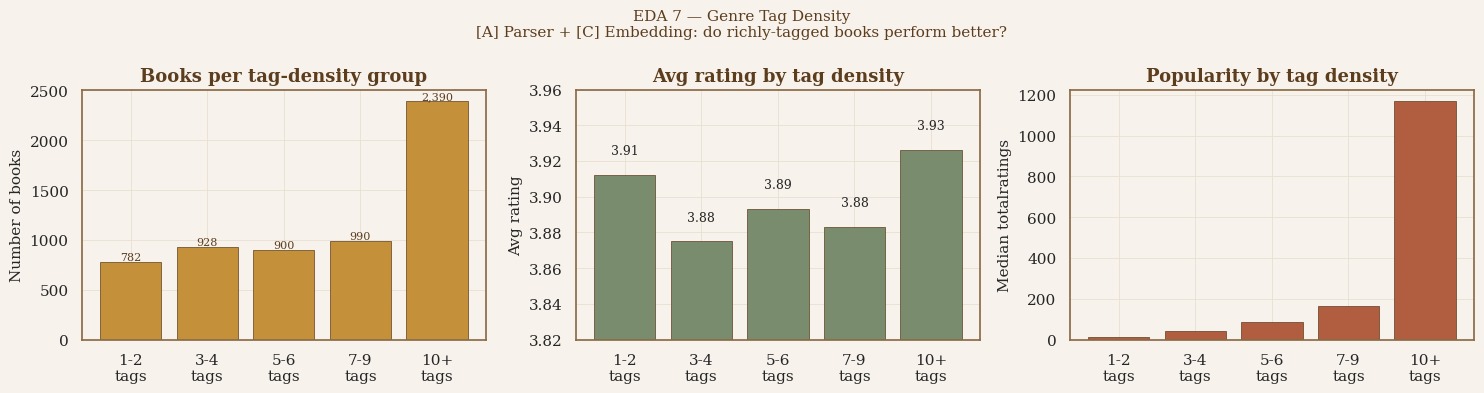

In [ ]:
# EDA 7: Genre tag density vs quality

tag_stats = books.groupby("tag_count").agg(
    n=("book_id","count"),
    avg_rating=("rating","mean"),
    med_totalratings=("totalratings","median"),
).round(3)

# Bucket into clean groups for plotting
books["tag_group"] = pd.cut(books["tag_count"],
                          bins=[0,2,4,6,9,16],
                          labels=["1-2\ntags","3-4\ntags","5-6\ntags",
                                  "7-9\ntags","10+\ntags"])
tg_stats = books.groupby("tag_group", observed=True).agg(
    n=("book_id","count"),
    avg_rating=("rating","mean"),
    med_pop=("totalratings","median"),
).round(3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(
    "EDA 7 — Genre Tag Density\n"
    "[A] Parser + [C] Embedding: do richly-tagged books perform better?",
    fontsize=11, color=C["brown"]
)

axes[0].bar(tg_stats.index, tg_stats["n"], color=C["gold"],
            edgecolor=C["brown"], linewidth=0.5)
axes[0].set_ylabel("Number of books")
axes[0].set_title("Books per tag-density group")
for i, v in enumerate(tg_stats["n"]):
    axes[0].text(i, v+20, f"{v:,}", ha="center", fontsize=8, color=C["brown"])

axes[1].bar(tg_stats.index, tg_stats["avg_rating"], color=C["sage"],
            edgecolor=C["brown"], linewidth=0.5)
axes[1].set_ylabel("Avg rating")
axes[1].set_title("Avg rating by tag density")
axes[1].set_ylim(3.82, 3.96)
annotate_bars_v(axes[1], tg_stats["avg_rating"].values)

axes[2].bar(tg_stats.index, tg_stats["med_pop"], color=C["terra"],
            edgecolor=C["brown"], linewidth=0.5)
axes[2].set_ylabel("Median totalratings")
axes[2].set_title("Popularity by tag density")

for ax in axes:
    ax.set_facecolor(C["cream"])
plt.tight_layout()

- Books with 10+ tags rate slightly higher (3.93) than 1-2 tag
    books (3.88) — richly-tagged books tend to be more mainstream
    and discoverable, attracting more nuanced readers
- 10+ tag books also have higher median popularity — these are the
    well-known genre-spanning titles (e.g. fantasy+romance+YA+paranormal)
- For the NLP parser: books with 10+ tags are the BEST candidates
    for cross-genre trope queries because they sit at genre intersections

=> Tag density as a retrieval boost:
      if query contains 2+ genre tropes => boost books with tag_count ≥ 8
      this surfaces genre-boundary books most likely to match multi-trope intent.


  Top 15 by content-based book score:
                                                                                                          title  rating  totalratings  word_count  book_score
                                                                                       A Thousand Splendid Suns    4.38       1218044         149    0.755089
                                                                                How the Grinch Stole Christmas!    4.34        353942         280    0.737176
                                                                                Written in My Own Heart's Blood    4.53         99846         189    0.722440
                                                                                       The Master and Margarita    4.29        262455         220    0.711912
                                                                                   Java Concurrency in Practice    4.46          2561         754    0.704831
             

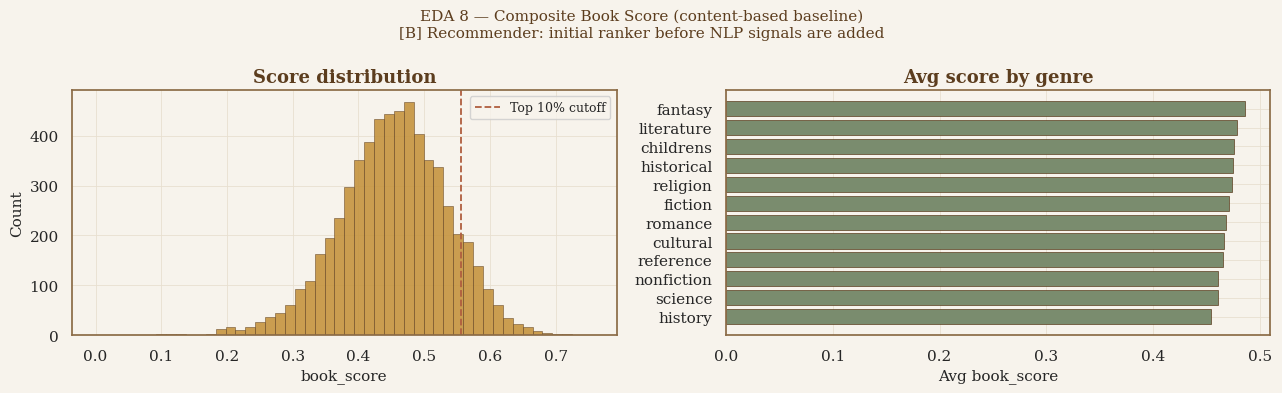

In [ ]:
# EDA 8: Composite book score

def minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

books["s_rating"] = minmax(books["rating"])
books["s_pop"]    = minmax(np.log1p(books["totalratings"]))
books["s_wc"]     = minmax(books["word_count"])

# Weights: rating quality (0.5) + log-popularity (0.35) + desc richness (0.15)
# rating is still useful as a relative signal within a genre cluster
# log-pop captures social proof; word_count captures content richness
books["book_score"] = (
    0.50 * books["s_rating"] +
    0.35 * books["s_pop"]    +
    0.15 * books["s_wc"]
)

top15 = (books[["title","author","genre_clean","rating","totalratings",
             "word_count","book_score"]]
         .sort_values("book_score", ascending=False).head(15))
print("\n  Top 15 by content-based book score:")
print(top15[["title","rating","totalratings","word_count","book_score"]]
      .to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(
    "EDA 8 — Composite Book Score (content-based baseline)\n"
    "[B] Recommender: initial ranker before NLP signals are added",
    fontsize=11, color=C["brown"]
)

axes[0].hist(books["book_score"], bins=50, color=C["gold"],
             edgecolor=C["brown"], linewidth=0.4, alpha=0.88)
axes[0].axvline(books["book_score"].quantile(0.9), color=C["terra"],
                linestyle="--", linewidth=1.3, label="Top 10% cutoff")
axes[0].set_xlabel("book_score")
axes[0].set_ylabel("Count")
axes[0].set_title("Score distribution")
axes[0].legend(fontsize=9)

# score by genre (top 12 exploded genres)
top12g = genre_freq.head(12).index.tolist()
genre_scores = {}
for g in top12g:
    mask = books["genre_clean"].str.contains(g, na=False)
    genre_scores[g] = books[mask]["book_score"].mean()
gs_series = pd.Series(genre_scores).sort_values()
axes[1].barh(gs_series.index, gs_series.values, color=C["sage"],
             edgecolor=C["brown"], linewidth=0.5)
axes[1].set_xlabel("Avg book_score")
axes[1].set_title("Avg score by genre")

for ax in axes:
    ax.set_facecolor(C["cream"])
plt.tight_layout()

- The composite book score provides a useful baseline ranking signal that integrates popularity and quality indicators before incorporating textual or semantic signals
- The composite score acts as an initial ranking layer, which can later be refined by NLP-based similarity and user interaction signals
- For books with limited interaction data, the composite score can serve as an initial ranking estimate based on available metadata

Top rated books

In [ ]:
book_sorted_ratings = books[books['totalratings']>=1000].sort_values('rating', ascending=False)
book_sorted_ratings[important_columns].head(15)

,book_id,title,author,genre_clean,desc_clean,rating,reviews,totalratings,isbn,isbn13,link
5891,51907,Searching for and Maintaining Peace: A Small T...,"Jacques Philippe,George Driscoll,Jannic Driscoll",christianity|catholic|religion|faith|spiritual...,this classic work is a short treatise on peace...,4.74,240,2551,818909064,9.78E+12,https://goodreads.com/book/show/1236244.Search...
5603,39456,Checkmate,Dorothy Dunnett,historical|historical fiction|fiction|cultural...,for the first time dunnett s lymond chronicles...,4.70,254,3314,679777482,9.78E+12,https://goodreads.com/book/show/112074.Checkmate
4878,18912,The Monster in the Hollows,"Andrew Peterson,Justin Gerard",fantasy|fiction|childrens|middle grade|young a...,book three of the wingfeather saga janner wing...,4.68,709,6276,982621434,9.78E+12,https://goodreads.com/book/show/10954417-the-m...
5736,45581,The Sibley Guide to Birds,"David Allen Sibley,National Audubon Society",reference|animals|birds|environment|nature|non...,the entire birding world from expert ornitholo...,4.68,109,2313,679451226,9.78068E+12,https://goodreads.com/book/show/15832.The_Sibl...
5889,46119,Mountaineering: The Freedom of the Hills,"The Mountaineers Club,Kris Fulsaas,Steven M. Cox",nonfiction|mountaineering|climbing|sports|natu...,the latest edition of the classic guide to mou...,4.58,157,3494,898868289,9.78E+12,https://goodreads.com/book/show/118565.Mountai...
5074,9213,Are Prisons Obsolete?,Angela Y. Davis,nonfiction|politics|race|social movements|soci...,with her characteristic brilliance grace and r...,4.55,1465,13892,1583225811,9.78E+12,https://goodreads.com/book/show/108428.Are_Pri...
4897,28859,Torn,Keisha Ervin,urban|fiction|romance|cultural|african america...,her female intuition told her he was a dog but...,4.54,151,2737,977880494,9.78098E+12,https://goodreads.com/book/show/1442921.Torn
5957,49174,Protector of the Small,Tamora Pierce,fantasy|young adult|fiction|magic|adventure|yo...,ten year old keladry of mindalen daughter of n...,4.53,110,9676,739446983,9.78074E+12,https://goodreads.com/book/show/153789.Protect...
5578,13391,Courageous,"Randy Alcorn,Alex Kendrick,Stephen Kendrick",christian fiction|christian|fiction|inspiratio...,retailers choice award winner 2012from the cre...,4.53,428,13599,1414358466,9.78E+12,https://goodreads.com/book/show/10790276-coura...
5718,13203,Written in My Own Heart's Blood,Diana Gabaldon,historical|historical fiction|romance|fiction|...,it is june 1778 and the world seems to be turn...,4.53,7186,99846,385344430,9.78E+12,https://goodreads.com/book/show/11710373-writt...


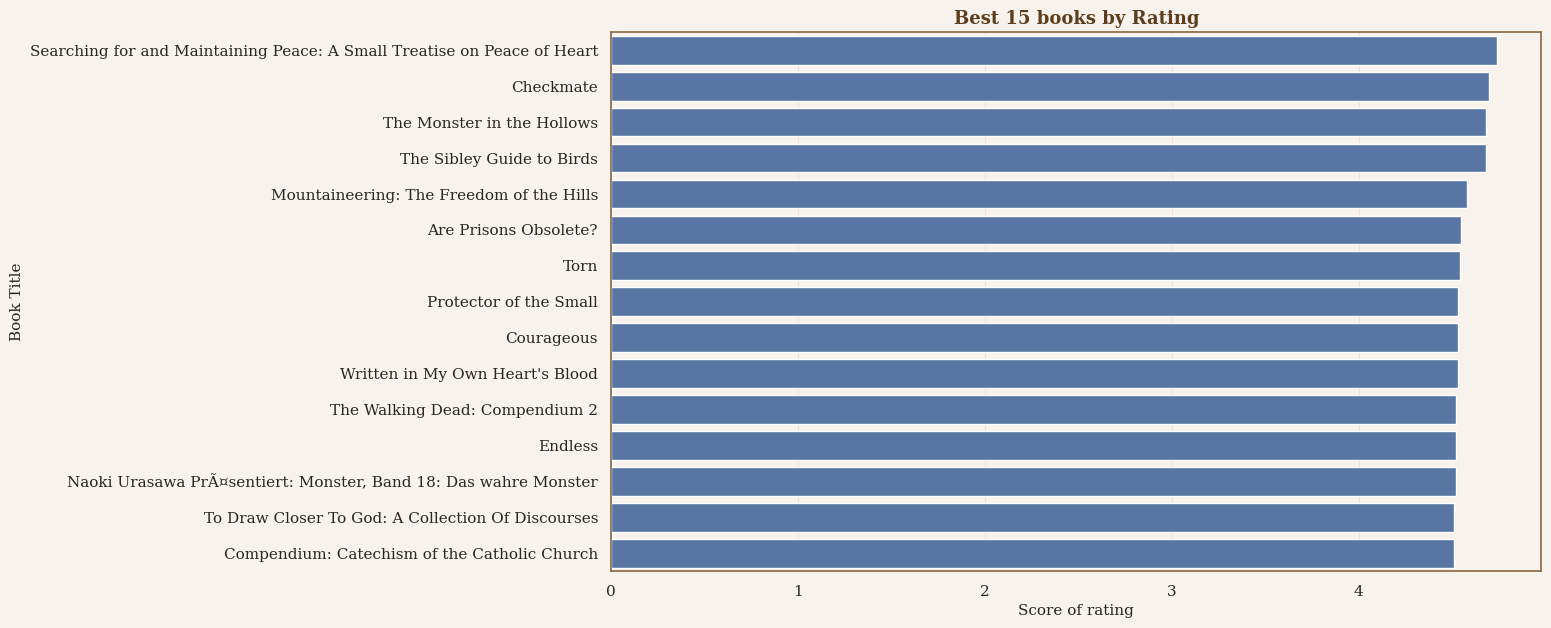

In [ ]:
plot_books_by(book_sorted_ratings, 'rating', 15)

Top popular books

In [ ]:
book_sorted_total_ratings = books.sort_values('totalratings', ascending=False)
book_sorted_total_ratings[important_columns].head(15)

,book_id,title,author,genre_clean,desc_clean,rating,reviews,totalratings,isbn,isbn13,link
5679,22343,Fahrenheit 451,Ray Bradbury,classics|fiction|science fiction|dystopia|acad...,guy montag is a fireman in his world where tel...,3.99,51835,1803486,NaN,NaN,https://goodreads.com/book/show/13079982-fahre...
5932,35736,The Golden Compass,Philip Pullman,fantasy|young adult|fiction|childrens|adventur...,lyra is rushing to the cold far north where wi...,3.99,23705,1344484,679879242,9.78E+12,https://goodreads.com/book/show/119322.The_Gol...
5088,18037,A Thousand Splendid Suns,Khaled Hosseini,fiction|historical|historical fiction|contempo...,a thousand splendid suns is a breathtaking sto...,4.38,57133,1218044,1594489505,9.78E+12,https://goodreads.com/book/show/128029.A_Thous...
4951,5957,The Odyssey,"Homer,Robert Fagles,Bernard Knox",classics|fiction|poetry|fantasy|mythology|acad...,sing to me of the man muse the man of twists a...,3.78,13300,898828,143039954,9.78014E+12,https://goodreads.com/book/show/1381.The_Odyssey
4941,22304,Fifty Shades Darker,E.L. James,romance|adult fiction|erotica|fiction|bdsm|adu...,daunted by the singular sexual tastes and dark...,3.84,29361,779074,1612130585,9.78E+12,https://goodreads.com/book/show/11857408-fifty...
5410,24237,In Cold Blood,Truman Capote,nonfiction|classics|crime|true crime|mystery|h...,on november 15 1959 in the small town of holco...,4.06,17804,563370,679745580,9.78068E+12,https://goodreads.com/book/show/168642.In_Cold...
5576,17069,A Midsummer Night's Dream,"William Shakespeare,Paul Werstine,Barbara A. M...",classics|plays|fiction|drama|fantasy|academic|...,shakespeare s intertwined love polygons begin ...,3.95,8592,460763,743477545,9.78074E+12,https://goodreads.com/book/show/1622.A_Midsumm...
4962,30874,The Voyage of the Dawn Treader,"C.S. Lewis,Pauline Baynes",fantasy|classics|fiction|young adult|childrens...,the dawn treader will take you places you neve...,4.08,7517,414676,006112527X,9.78006E+12,https://goodreads.com/book/show/140225.The_Voy...
5641,4123,How the Grinch Stole Christmas!,Dr. Seuss,childrens|picture books|holiday|christmas|clas...,the grinch hated christmas the whole christmas...,4.34,3545,353942,7173040,9.78E+12,https://goodreads.com/book/show/113946.How_the...
5977,19205,Good in Bed,Jennifer Weiner,womens fiction|chick lit|fiction|romance|conte...,weiner s witty original fast moving debut feat...,3.73,6000,286952,743418174,9.78074E+12,https://goodreads.com/book/show/14748.Good_in_Bed


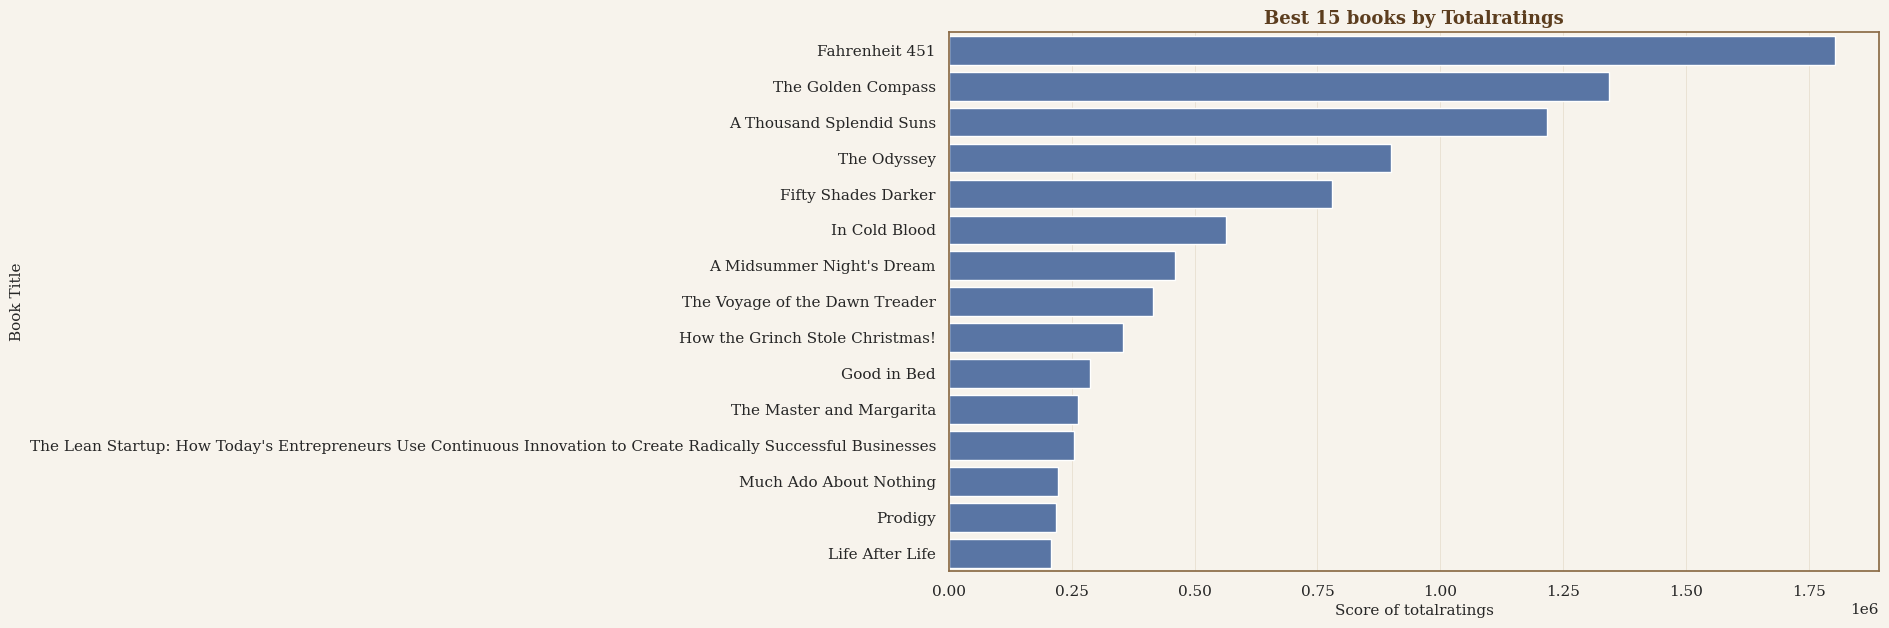

In [ ]:
plot_books_by(book_sorted_total_ratings, 'totalratings', 15)

Top Review Books

In [ ]:
book_sorted_total_reviews = books[books['totalratings']>=1000].sort_values('reviews', ascending=False)
book_sorted_total_reviews[important_columns].head(15)

,book_id,title,author,genre_clean,desc_clean,rating,reviews,totalratings,isbn,isbn13,link
5088,18037,A Thousand Splendid Suns,Khaled Hosseini,fiction|historical|historical fiction|contempo...,a thousand splendid suns is a breathtaking sto...,4.38,57133,1218044,1594489505,9.78E+12,https://goodreads.com/book/show/128029.A_Thous...
5679,22343,Fahrenheit 451,Ray Bradbury,classics|fiction|science fiction|dystopia|acad...,guy montag is a fireman in his world where tel...,3.99,51835,1803486,NaN,NaN,https://goodreads.com/book/show/13079982-fahre...
4941,22304,Fifty Shades Darker,E.L. James,romance|adult fiction|erotica|fiction|bdsm|adu...,daunted by the singular sexual tastes and dark...,3.84,29361,779074,1612130585,9.78E+12,https://goodreads.com/book/show/11857408-fifty...
4892,30258,Life After Life,Kate Atkinson,fiction|historical|historical fiction|fantasy|...,what if you could live again and again until y...,3.76,24729,207029,316176486,9.78032E+12,https://goodreads.com/book/show/15790842-life-...
5932,35736,The Golden Compass,Philip Pullman,fantasy|young adult|fiction|childrens|adventur...,lyra is rushing to the cold far north where wi...,3.99,23705,1344484,679879242,9.78E+12,https://goodreads.com/book/show/119322.The_Gol...
5410,24237,In Cold Blood,Truman Capote,nonfiction|classics|crime|true crime|mystery|h...,on november 15 1959 in the small town of holco...,4.06,17804,563370,679745580,9.78068E+12,https://goodreads.com/book/show/168642.In_Cold...
5206,13078,The Sense of an Ending,Julian Barnes,fiction|contemporary|literary fiction|literatu...,by an acclaimed writer at the height of his po...,3.73,16481,156819,224094157,9.78E+12,https://goodreads.com/book/show/10746542-the-s...
5861,19772,Angelfall,Susan Ee,fantasy|young adult|paranormal|angels|science ...,it s been six weeks since angels of the apocal...,4.11,16056,178581,NaN,NaN,https://goodreads.com/book/show/15863832-angel...
5172,36501,Prodigy,Marie Lu,science fiction|dystopia|young adult|romance|f...,injured and on the run it has been seven days ...,4.25,15930,217053,399256768,9.78E+12,https://goodreads.com/book/show/13414446-prodigy
5741,12174,Wallbanger,Alice Clayton,romance|contemporary|contemporary romance|humo...,the first night after caroline moves into her ...,4.03,13867,185808,1623420024,9.78162E+12,https://goodreads.com/book/show/15858248-wallb...


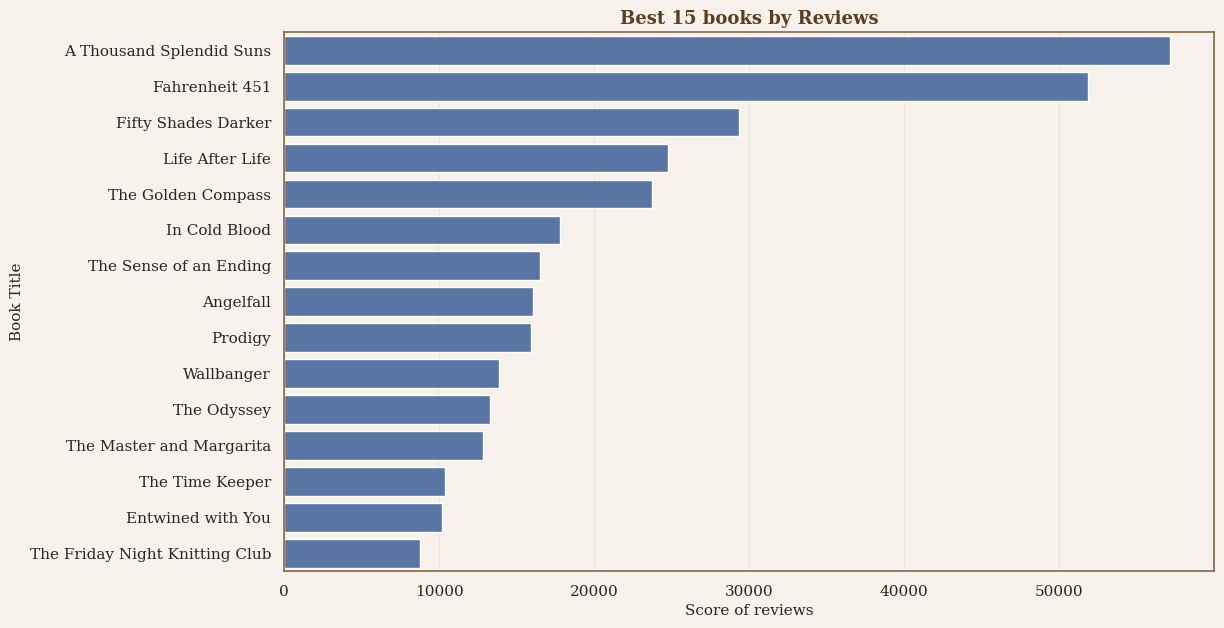

In [ ]:
plot_books_by(book_sorted_total_reviews, 'reviews', 15)

Top Scrored Books

In [ ]:
# We need to normalize average_rating & ratings_count to have the same scale.
cols = ['totalratings','rating']
scaler = MinMaxScaler()
df_normalized = books[important_columns].copy()
df_normalized[cols] = scaler.fit_transform(df_normalized[cols])

In [ ]:
df_normalized.head()

,book_id,title,author,genre_clean,desc_clean,rating,reviews,totalratings,isbn,isbn13,link
0,20385,The Art of Haute Couture,"Victor Skrebneski,Victor Skrebneski",couture|fashion|art,illustrated with victor skrebneski s closeups ...,0.713333,0,0.000003,789200228,9.78079E+12,https://goodreads.com/book/show/1455361.The_Ar...
1,17418,"The Foundations of Modern Terrorism: State, So...",Martin A. Miller,war|terrorism,why is it that terrorism has become such a cen...,0.586667,1,0.000009,113960385X,9.78114E+12,https://goodreads.com/book/show/17137531-the-f...
2,3525,"Country House Brewing in England, 1500-1900",Pamela A. Sambrook,alcohol|beer|history,until the eighteenth century or even later bee...,0.666667,0,0.000003,1852851279,9.78185E+12,https://goodreads.com/book/show/1714952.Countr...
3,6740,The Essential Lapsit Guide an Multimedia How-T...,Linda L. Ernst,science|library science,this innovative comprehensive resource will he...,0.556667,0,0.000001,1555707610,9.78156E+12,https://goodreads.com/book/show/14431761-the-e...
4,4745,Endless Appetites: How the Commodities Casino ...,Alan Bjerga,food and drink|food,how to understand the twenty first century foo...,0.583333,4,0.000011,1118043235,9.78E+12,https://goodreads.com/book/show/12898732-endle...


In [ ]:
# Feature Engineering
# Create a new scorer for books by combining average_rating & ratings_count with ratios 0.6 : 0.4
df_normalized['book_score'] = 0.6 * df_normalized['totalratings'] + 0.4 * df_normalized['rating']

In [ ]:
df_normalized_sorted_score = df_normalized.sort_values('book_score', ascending=False)
df_normalized_sorted_score.head()

,book_id,title,author,genre_clean,desc_clean,rating,reviews,totalratings,isbn,isbn13,link,book_score
5679,22343,Fahrenheit 451,Ray Bradbury,classics|fiction|science fiction|dystopia|acad...,guy montag is a fireman in his world where tel...,0.663333,51835,1.000000,NaN,NaN,https://goodreads.com/book/show/13079982-fahre...,0.865333
5088,18037,A Thousand Splendid Suns,Khaled Hosseini,fiction|historical|historical fiction|contempo...,a thousand splendid suns is a breathtaking sto...,0.793333,57133,0.675383,1594489505,9.78E+12,https://goodreads.com/book/show/128029.A_Thous...,0.722563
5932,35736,The Golden Compass,Philip Pullman,fantasy|young adult|fiction|childrens|adventur...,lyra is rushing to the cold far north where wi...,0.663333,23705,0.745492,679879242,9.78E+12,https://goodreads.com/book/show/119322.The_Gol...,0.712628
4951,5957,The Odyssey,"Homer,Robert Fagles,Bernard Knox",classics|fiction|poetry|fantasy|mythology|acad...,sing to me of the man muse the man of twists a...,0.593333,13300,0.498383,143039954,9.78014E+12,https://goodreads.com/book/show/1381.The_Odyssey,0.536363
4941,22304,Fifty Shades Darker,E.L. James,romance|adult fiction|erotica|fiction|bdsm|adu...,daunted by the singular sexual tastes and dark...,0.613333,29361,0.431982,1612130585,9.78E+12,https://goodreads.com/book/show/11857408-fifty...,0.504523


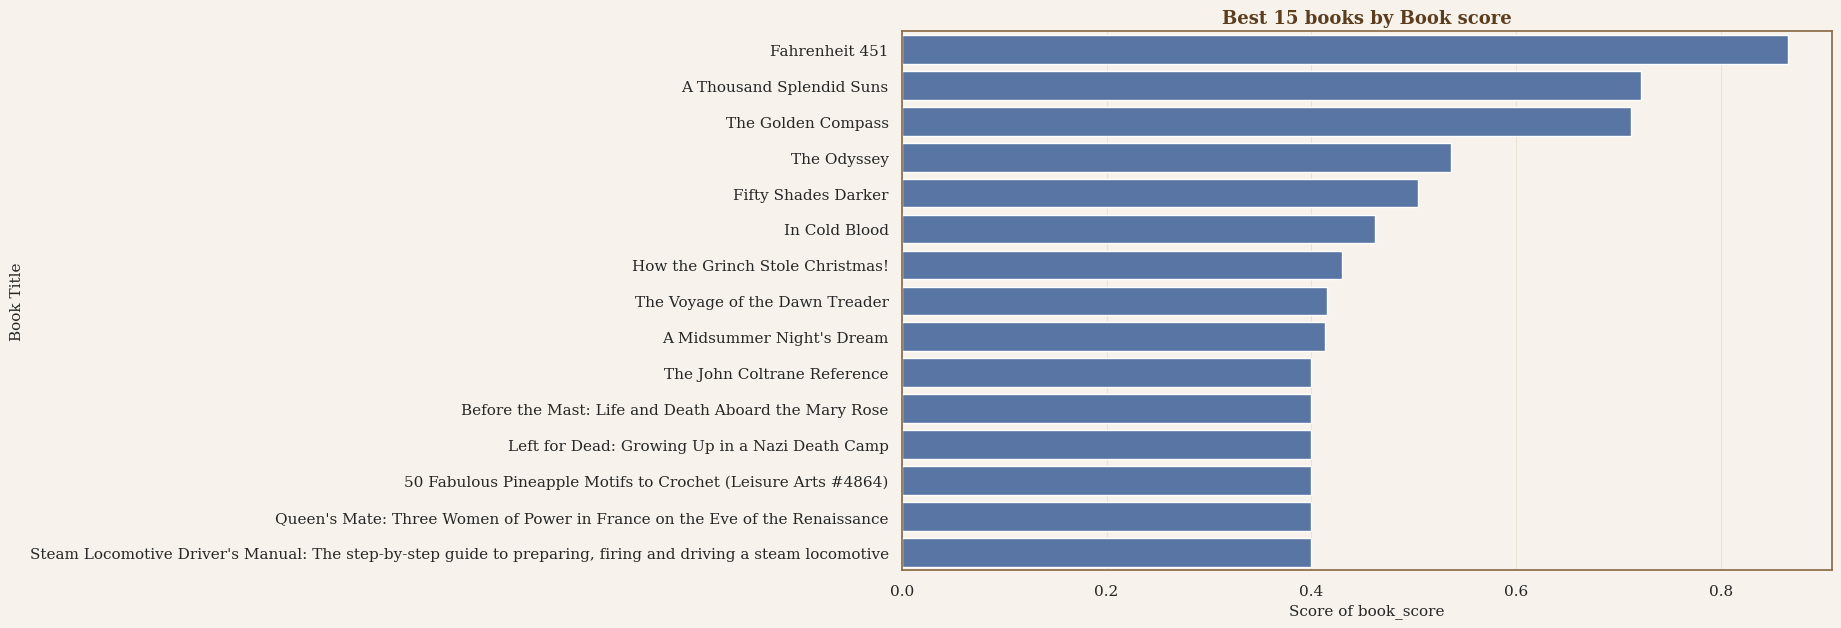

In [ ]:
plot_books_by(df_normalized_sorted_score, 'book_score', 15)

B. EDA FOR AUTHORS

1. Feature engineering

In [ ]:
books.author.value_counts().reset_index()

,author,count
0,Lynne Graham,10
1,Bonnie Bryant,8
2,Elinor M. Brent-Dyer,7
3,Mercedes Lackey,6
4,R.L. Stine,6
...,...,...
5574,"Len Wein,Dick Giordano,JosÃ© Luis GarcÃ­a-LÃ³pez",1
5575,Jerry Spinelli,1
5576,"Luke Hunter,Priscilla Barrett",1
5577,"Robert Gendler,Neil deGrasse Tyson",1


In [ ]:
a = []
books.author.apply(lambda x: a.append(x) if ',' in x else [])
a[:10]

['Victor Skrebneski,Victor Skrebneski',
 'C. Lee Harrington,Denise D. Bielby',
 'Rick Halpern,Roger Horowitz',
 'Robert Gendler,Neil deGrasse Tyson',
 'Luke Hunter,Priscilla Barrett',
 'Fiona Cameron,Lynda Kelly',
 'Stephen Wagg,David Andrews',
 'Steven S. Long,Christian Moore,Kenneth Hite,Owen Seyler',
 'Robert Lyons,Najsib Ma=hfsu=z',
 'The New York Times,The New York Times']

In [ ]:
print('Number of books with multi-authors is {}.'.format(len(a)))

Number of books with multi-authors is 1620.


In [ ]:
authors_list = books['author'].apply(lambda x: [a for a in x.split(', ')] if ',' in x else x)
authors_list.head()

# For multi-authors books, split their authors with a copy of the book for each one.
splitted_author = authors_list.apply(lambda x: pd.Series(x)).stack().reset_index(level=1, drop=True)
splitted_author.name = 'author'
splitted_author.head()

,author
0,"Victor Skrebneski,Victor Skrebneski"
1,Martin A. Miller
2,Pamela A. Sambrook
3,Linda L. Ernst
4,Alan Bjerga


In [ ]:
edited_author = books[important_columns].drop('author', axis=1).join(splitted_author)
edited_author.head()

,book_id,title,genre_clean,desc_clean,rating,reviews,totalratings,isbn,isbn13,link,author
0,20385,The Art of Haute Couture,couture|fashion|art,illustrated with victor skrebneski s closeups ...,4.14,0,7,789200228,9.78079E+12,https://goodreads.com/book/show/1455361.The_Ar...,"Victor Skrebneski,Victor Skrebneski"
1,17418,"The Foundations of Modern Terrorism: State, So...",war|terrorism,why is it that terrorism has become such a cen...,3.76,1,17,113960385X,9.78114E+12,https://goodreads.com/book/show/17137531-the-f...,Martin A. Miller
2,3525,"Country House Brewing in England, 1500-1900",alcohol|beer|history,until the eighteenth century or even later bee...,4.00,0,7,1852851279,9.78185E+12,https://goodreads.com/book/show/1714952.Countr...,Pamela A. Sambrook
3,6740,The Essential Lapsit Guide an Multimedia How-T...,science|library science,this innovative comprehensive resource will he...,3.67,0,3,1555707610,9.78156E+12,https://goodreads.com/book/show/14431761-the-e...,Linda L. Ernst
4,4745,Endless Appetites: How the Commodities Casino ...,food and drink|food,how to understand the twenty first century foo...,3.75,4,20,1118043235,9.78E+12,https://goodreads.com/book/show/12898732-endle...,Alan Bjerga


In [ ]:
books.shape, edited_author.shape

((5990, 28), (5991, 11))

In [ ]:
edited_author.author.value_counts()

,count
author,
Lynne Graham,10
Bonnie Bryant,8
Elinor M. Brent-Dyer,7
Mercedes Lackey,6
R.L. Stine,6
...,...
"Len Wein,Dick Giordano,JosÃ© Luis GarcÃ­a-LÃ³pez",1
Jerry Spinelli,1
Barry Eisler,1


2. EDA for Authors

In [ ]:
def plot_author_by(df, title, xlabel, n=15, ylabel='Author', y_size=7):
    plt.figure(figsize=(15,y_size))
    ax = sns.barplot(x=df.head(n).values, y=df.head(n).index)
    plt.title(title, weight='bold')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

In [ ]:
# Feature egineering
# Filter authors by their number of books & total ratings count
def at_least_books(df, n):
    more_than_n = edited_author['author'].value_counts().values >= n
    return df['author'].isin(df['author'].value_counts()[more_than_n == True].index)

Best Rating Authors

In [ ]:
def at_least_total_ratings(df, n):
    return df.totalratings >= n

In [ ]:
c1 = at_least_books(edited_author,2)
c2 = at_least_total_ratings(edited_author, 2000)

In [ ]:
best_rating_author = edited_author[c1 & c2].groupby('author')['rating'].mean().sort_values(ascending=False)
best_rating_author.head(15)

,rating
author,
Robert Barron,4.500000
Jessica Shirvington,4.455000
David Attenborough,4.430000
Masashi Kishimoto,4.355000
Lynette Eason,4.355000
Meca Tanaka,4.340000
Max Lucado,4.330000
Mo Willems,4.325000
Ravi Zacharias,4.320000


In [ ]:
print('Best Rating Authors are {} of {} authors'.format(len(best_rating_author),len(edited_author.author.unique())))

Best Rating Authors are 105 of 5580 authors


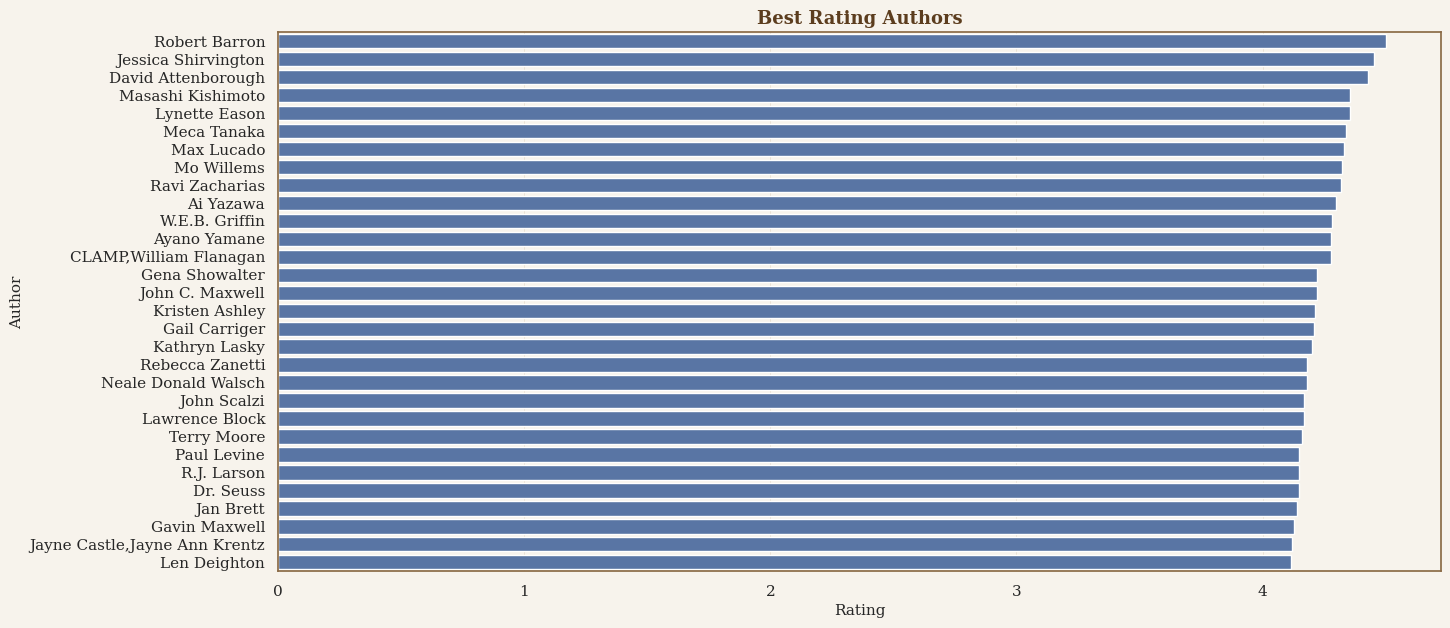

In [ ]:
plot_author_by(best_rating_author, 'Best Rating Authors', 'Rating', 30)

Most Rating Authors

In [ ]:
most_ratings_author = edited_author.groupby('author')['totalratings'].sum().sort_values(ascending=False)
most_ratings_author.head(15)

,totalratings
author,
Ray Bradbury,1803486
Philip Pullman,1344484
Khaled Hosseini,1218044
"Homer,Robert Fagles,Bernard Knox",898828
E.L. James,779074
Truman Capote,563370
"William Shakespeare,Paul Werstine,Barbara A. Mowat,Catherine Belsey",460763
Dr. Seuss,429231
"C.S. Lewis,Pauline Baynes",414842


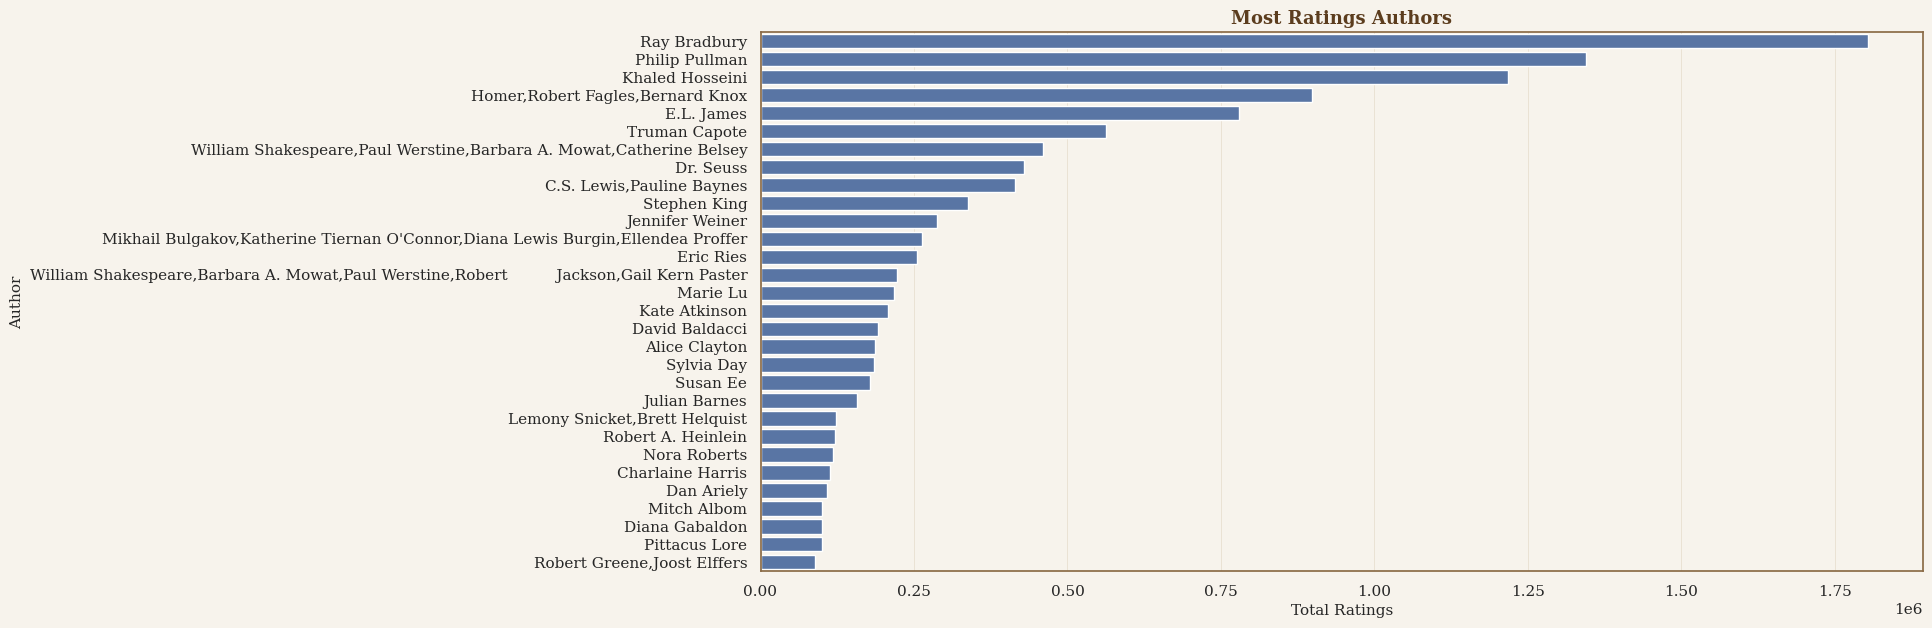

In [ ]:
plot_author_by(most_ratings_author, 'Most Ratings Authors', 'Total Ratings', 30)

Books and Authors rated show some recommendation for users who do not have special requirements about tropes or just simply new users to goodreads and start reading by top popular

B. EDA COMBINING BOOKS DATASET AND REVIEW DATASET

In [ ]:
reviews = pd.read_csv("/content/book_nlp_features.csv")
reviews.head()

,book_id,title,author_clean,genre_primary,genre_clean,top_keywords,avg_polarity,avg_subjectivity,avg_rating,review_count,liked_ratio,dominant_sentiment
0,11,"certain to win: the strategy of john boyd, app...",chet richards,business,business|management|nonfiction|leadership|war|...,"strategy, business, loop, warfare, war, you, t...",0.2159,0.5051,4.2000,15,0.7333,positive
1,12,the zigzag principle: the goal setting strateg...,rich christiansen,business,business|entrepreneurship|self help|leadership...,"business, principle, you, your, goal, resource...",0.2416,0.4714,4.1667,12,0.8333,positive
2,13,chancellorsville's forgotten front: the battle...,"chris mackowski,kristopher d. white",military history,military history|civil war|history|american hi...,"campaign, church, union, battle, army, jackson...",0.3112,0.5231,4.2857,7,0.8571,positive
3,25,java concurrency in practice,"brian goetz,tim peierls,joshua bloch,joseph bo...",computer science,computer science|programming|science|technolog...,"programming, code, program, developer, thread,...",0.1798,0.4783,4.6923,26,1.0000,positive
4,46,a dream foreclosed: black america and the figh...,"laura gottesdiener,clarence lusane,r. black,ja...",nonfiction,nonfiction|social movements|social justice,"housing, crisis, african, african american, la...",0.1132,0.4592,4.2500,8,1.0000,positive


In [ ]:
C = {
    "brown":  "#5C3D1E", "gold":   "#C4913A",
    "sage":   "#7A8C6E", "terra":  "#B05E3F",
    "cream":  "#F7F3EC", "muted":  "#8B6B47",
    "purple": "#6B5A8E", "teal":   "#3A7068",
}
SENT_PAL = {"positive": C["sage"], "neutral": C["gold"], "negative": C["terra"]}

sns.set_theme(style="whitegrid", font="serif")
plt.rcParams.update({
    "figure.facecolor": C["cream"], "axes.facecolor": C["cream"],
    "axes.edgecolor":   C["muted"], "axes.titlesize":  13,
    "axes.labelsize":   11,         "grid.color":      "#E8DFD0",
    "grid.linewidth":   0.6,        "axes.titleweight": "bold",
    "axes.titlecolor":  C["brown"],
})

def save(name):
    plt.savefig(f"nlp_figures/{name}.png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  → saved nlp_figures/{name}.png")

def bar_label(ax, values, fmt="{:.2f}", offset=0.005, fontsize=9):
    for i, v in enumerate(values):
        ax.text(i, v + offset, fmt.format(v),
                ha="center", fontsize=fontsize, color=C["brown"])

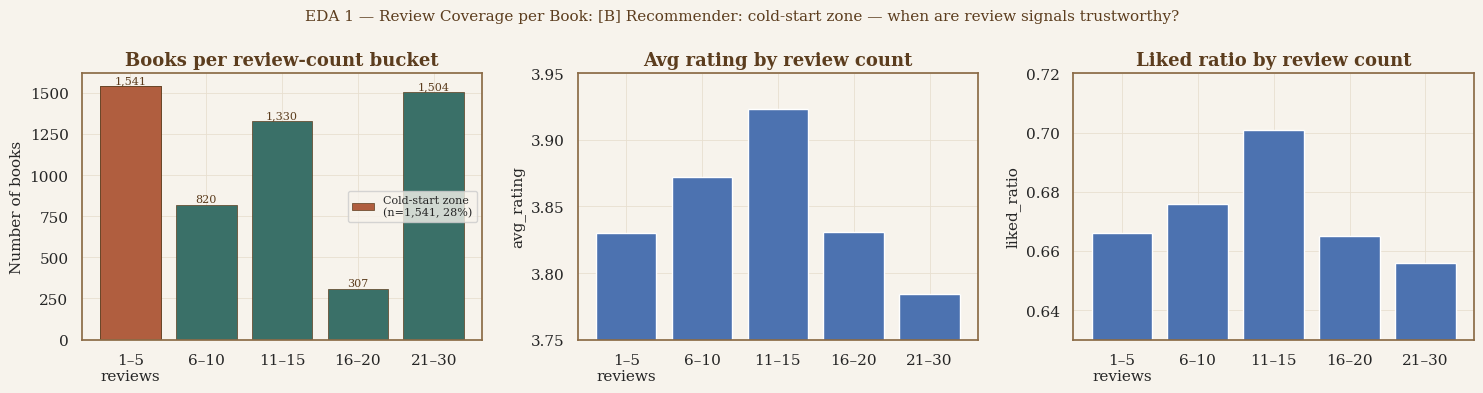

In [ ]:
# EDA 1: Review coverage

rc_bins  = [0, 5, 10, 15, 20, 30]
rc_labels = ["1–5\nreviews", "6–10", "11–15", "16–20", "21–30"]
reviews["rc_bin"] = pd.cut(reviews["review_count"], bins=rc_bins, labels=rc_labels)
rc_stats = reviews.groupby("rc_bin", observed=True).agg(
    n          = ("book_id",      "count"),
    avg_rating = ("avg_rating",   "mean"),
    liked_ratio= ("liked_ratio",  "mean"),
    avg_polarity=("avg_polarity", "mean"),
).round(3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(
    "EDA 1 — Review Coverage per Book: [B] Recommender: cold-start zone — when are review signals trustworthy?",
    fontsize=11, color=C["brown"]
)

# left — book count per review-count bucket
axes[0].bar(rc_labels, rc_stats["n"], color=C["teal"],
            edgecolor=C["brown"], linewidth=0.5)
axes[0].set_ylabel("Number of books")
axes[0].set_title("Books per review-count bucket")
cold_n = rc_stats.loc["1–5\nreviews", "n"]
axes[0].bar(rc_labels[:1], rc_stats["n"].iloc[:1],
            color=C["terra"], edgecolor=C["brown"], linewidth=0.5,
            label=f"Cold-start zone\n(n={cold_n:,}, "
                  f"{cold_n/len(reviews)*100:.0f}%)")
axes[0].legend(fontsize=8)
for i, v in enumerate(rc_stats["n"]):
    axes[0].text(i, v + 18, f"{v:,}", ha="center", fontsize=8, color=C["brown"])

# middle — avg_rating per bucket
axes[1].bar(rc_labels, rc_stats["avg_rating"], color=C["gold"],
            edgecolor=C["brown"], linewidth=0.5)
axes[1].set_ylabel("avg_rating")
axes[1].set_title("Avg rating by review count")
axes[1].set_ylim(3.75, 3.95)
bars = axes[1].bar(rc_stats.index, rc_stats["avg_rating"])

# right — liked_ratio per bucket
axes[2].bar(rc_labels, rc_stats["liked_ratio"], color=C["sage"],
            edgecolor=C["brown"], linewidth=0.5)
axes[2].set_ylabel("liked_ratio")
axes[2].set_title("Liked ratio by review count")
axes[2].set_ylim(0.63, 0.72)
bars = axes[2].bar(rc_stats.index, rc_stats["liked_ratio"])

for ax in axes:
    ax.set_facecolor(C["cream"])
plt.tight_layout()

- 1541 books of 28% have only 1–5 reviews — cold-start zone
- avg_rating and liked_ratio are least stable in the 1–5 bucket
- Quality peaks at 11–15 reviews, then dips for 21–30 — books with
    many reviews attract more diverse (sometimes critical) audiences

=> Cold-start rule for the recommender:
      review_count ≤ 5  → rank by avg_polarity  (NLP signal, not crowd-based)
      review_count > 5  → rank by liked_ratio   (crowd-validated signal)

This ensures 28% of the catalog is still rankable via NLP quality proxy

                  avg_polarity  avg_subjectivity  avg_rating  liked_ratio  review_count
avg_polarity             1.000             0.343       0.316        0.273        -0.117
avg_subjectivity         0.343             1.000       0.076        0.065         0.107
avg_rating               0.316             0.076       1.000        0.886        -0.033
liked_ratio              0.273             0.065       0.886        1.000        -0.016
review_count            -0.117             0.107      -0.033       -0.016         1.000


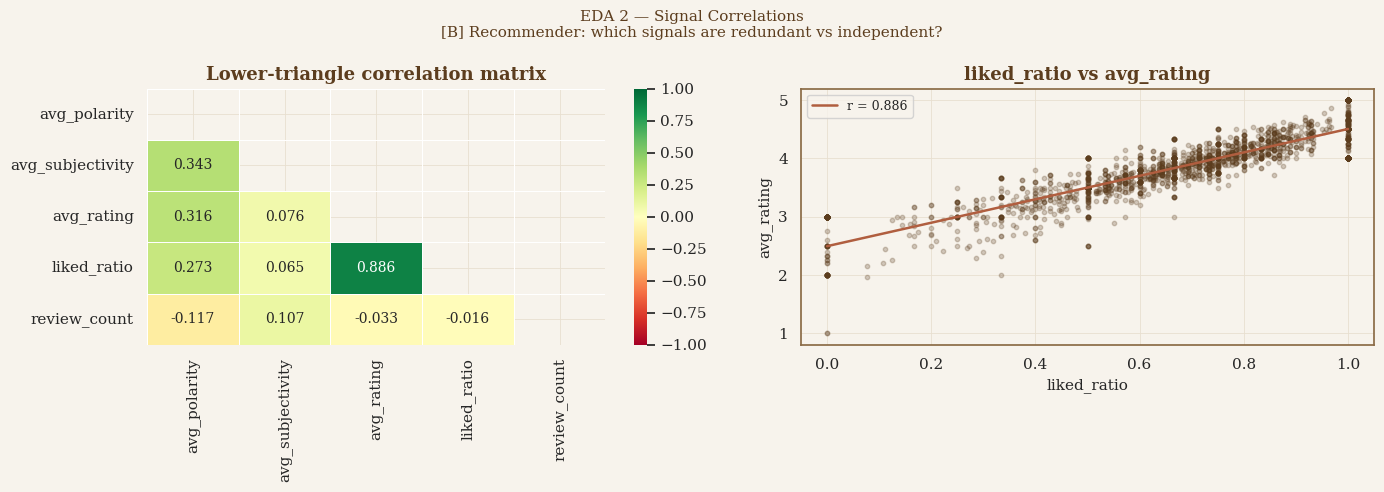

In [ ]:
# EDA 2: Signal correlations — recommender feature selection

num_cols = ["avg_polarity","avg_subjectivity","avg_rating",
            "liked_ratio","review_count"]
corr = reviews[num_cols].corr().round(3)
print(corr.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "EDA 2 — Signal Correlations\n"
    "[B] Recommender: which signals are redundant vs independent?",
    fontsize=11, color=C["brown"]
)

# left — heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".3f",
            cmap="RdYlGn", center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=axes[0], annot_kws={"size": 10})
axes[0].set_title("Lower-triangle correlation matrix")
axes[0].set_facecolor(C["cream"])

# right — scatter: liked_ratio vs avg_rating (the key redundancy)
sample = reviews.sample(min(2000, len(reviews)), random_state=42)
axes[1].scatter(sample["liked_ratio"], sample["avg_rating"],
                alpha=0.25, s=10, color=C["brown"])
m, b = np.polyfit(sample["liked_ratio"], sample["avg_rating"], 1)
xr = np.linspace(0, 1, 100)
axes[1].plot(xr, m*xr+b, color=C["terra"], linewidth=1.8,
             label=f"r = {corr.loc['liked_ratio','avg_rating']:.3f}")
axes[1].set_xlabel("liked_ratio")
axes[1].set_ylabel("avg_rating")
axes[1].set_title("liked_ratio vs avg_rating")
axes[1].legend(fontsize=9)
axes[1].set_facecolor(C["cream"])

plt.tight_layout()

Feature selection for recommender
- liked_ratio ↔ avg_rating: r = 0.88 => nearly redundant.
    They carry almost the same information. Use liked_ratio as primary
    (clean 0-1 scale, interpretable) and avg_rating as a lightweight backup
- avg_polarity ↔ liked_ratio: r = 0.27 => moderate, independent.
    Polarity adds value that crowd signals don't capture, especially
    in the cold-start zone (≤5 reviews).
- avg_subjectivity: r ≈ 0 with avg_rating and liked_ratio => Drop avg_subjectivity from all recommender features — zero signal.
- review_count: slightly NEGATIVE correlation with quality (r = -0.033) => More reviews ≠ better book; log-compress and use only as confidence weight.

=> Final feature set: [liked_ratio, avg_rating, avg_polarity, log(review_count) and Drop: avg_subjectivity

                    avg_rating  liked_ratio  avg_polarity
dominant_sentiment                                       
negative                 3.327        0.464        -0.085
neutral                  3.583        0.573         0.093
positive                 3.897        0.693         0.213


/tmp/ipykernel_410/640418375.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


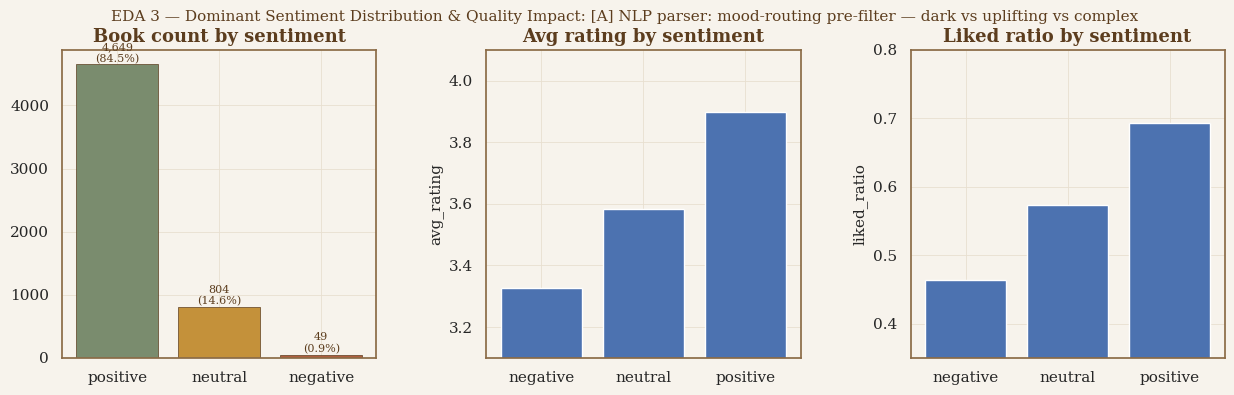

In [ ]:
# EDA 3: Dominant sentiment — mood-matching layer

sent_counts = reviews["dominant_sentiment"].value_counts()
sent_stats  = reviews.groupby("dominant_sentiment")[
    ["avg_rating","liked_ratio","avg_polarity"]].mean().round(3)
print(sent_stats.to_string())

fig = plt.figure(figsize=(15, 4))
fig.suptitle(
    "EDA 3 — Dominant Sentiment Distribution & Quality Impact: [A] NLP parser: mood-routing pre-filter — dark vs uplifting vs complex",
    fontsize=11, color=C["brown"]
)
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)
axes = [fig.add_subplot(gs[i]) for i in range(3)]

# count with pct labels
axes[0].bar(sent_counts.index, sent_counts.values,
            color=[SENT_PAL[s] for s in sent_counts.index],
            edgecolor=C["brown"], linewidth=0.5)
axes[0].set_title("Book count by sentiment")
for i, (s, v) in enumerate(sent_counts.items()):
    axes[0].text(i, v + 40, f"{v:,}\n({v/len(reviews)*100:.1f}%)",
                 ha="center", fontsize=8, color=C["brown"])

# avg_rating by sentiment
axes[1].bar(sent_stats.index, sent_stats["avg_rating"],
            color=[SENT_PAL[s] for s in sent_stats.index],
            edgecolor=C["brown"], linewidth=0.5)
axes[1].set_title("Avg rating by sentiment")
axes[1].set_ylabel("avg_rating")
axes[1].set_ylim(3.1, 4.1)
bars = axes[1].bar(sent_stats.index, sent_stats["avg_rating"])

# liked_ratio by sentiment
axes[2].bar(sent_stats.index, sent_stats["liked_ratio"],
            color=[SENT_PAL[s] for s in sent_stats.index],
            edgecolor=C["brown"], linewidth=0.5)
axes[2].set_title("Liked ratio by sentiment")
axes[2].set_ylabel("liked_ratio")
axes[2].set_ylim(0.35, 0.80)
bars = axes[2].bar(sent_stats.index, sent_stats["liked_ratio"])

for ax in axes:
    ax.set_facecolor(C["cream"])
plt.tight_layout()

- 84.5% positive, 14.6% neutral, 0.9% negative — catalog skews warm.
- Quality gap: positive vs negative books have enormous gap of 80%
- Negative books (n=49) are the "dark/intense" niche — rare but
    critical for queries like "grimdark", "tragedy", "psychological horror".

=> Mood routing in the NLP query parser:
      "uplifting / cozy / feel-good"    → sentiment = positive

      "dark / grim / tragic / intense"  → sentiment IN (neutral, negative)

      "complex / bittersweet"           → all sentiments, sort avg_polarity ↑

      tone not specified                → no filter, rank by liked_ratio

/tmp/ipykernel_410/2479257287.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(pol_stats.index, fontsize=7.5)
/tmp/ipykernel_410/2479257287.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(pol_stats.index, fontsize=7.5)


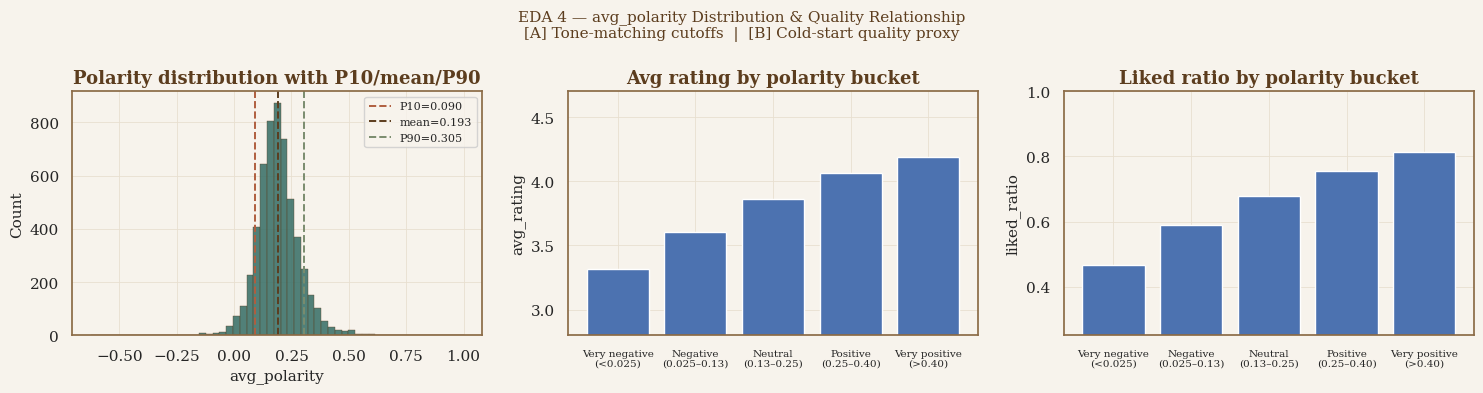

In [ ]:
# EDA 4: avg_polarity — tone signal & cold-start proxy

p10 = reviews["avg_polarity"].quantile(0.10)
p25 = reviews["avg_polarity"].quantile(0.25)
p75 = reviews["avg_polarity"].quantile(0.75)
p90 = reviews["avg_polarity"].quantile(0.90)

reviews["pol_bin"] = pd.cut(
    reviews["avg_polarity"],
    bins=[-1, 0.025, 0.13, 0.25, 0.40, 1.0],
    labels=["Very negative\n(<0.025)", "Negative\n(0.025–0.13)",
            "Neutral\n(0.13–0.25)", "Positive\n(0.25–0.40)",
            "Very positive\n(>0.40)"]
)
pol_stats = reviews.groupby("pol_bin", observed=True).agg(
    n          = ("book_id",      "count"),
    avg_rating = ("avg_rating",   "mean"),
    liked_ratio= ("liked_ratio",  "mean"),
).round(3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(
    "EDA 4 — avg_polarity Distribution & Quality Relationship\n"
    "[A] Tone-matching cutoffs  |  [B] Cold-start quality proxy",
    fontsize=11, color=C["brown"]
)

# distribution with key thresholds
axes[0].hist(reviews["avg_polarity"], bins=55,
             color=C["teal"], edgecolor=C["brown"], linewidth=0.3, alpha=0.88)
for val, label, col in [
    (p10, "P10", C["terra"]),
    (reviews["avg_polarity"].mean(), "mean", C["brown"]),
    (p90, "P90", C["sage"]),
]:
    axes[0].axvline(val, color=col, linestyle="--", linewidth=1.4,
                    label=f"{label}={val:.3f}")
axes[0].set_xlabel("avg_polarity")
axes[0].set_ylabel("Count")
axes[0].set_title("Polarity distribution with P10/mean/P90")
axes[0].legend(fontsize=8)

# avg_rating per polarity bucket
colors_pol = [C["terra"], C["muted"], C["gold"], C["sage"], C["teal"]]
axes[1].bar(pol_stats.index, pol_stats["avg_rating"],
            color=colors_pol, edgecolor=C["brown"], linewidth=0.5)
axes[1].set_xticklabels(pol_stats.index, fontsize=7.5)
axes[1].set_ylabel("avg_rating")
axes[1].set_title("Avg rating by polarity bucket")
axes[1].set_ylim(2.8, 4.7)
bars = axes[1].bar(pol_stats.index, pol_stats["avg_rating"])

# liked_ratio per polarity bucket
axes[2].bar(pol_stats.index, pol_stats["liked_ratio"],
            color=colors_pol, edgecolor=C["brown"], linewidth=0.5)
axes[2].set_xticklabels(pol_stats.index, fontsize=7.5)
axes[2].set_ylabel("liked_ratio")
axes[2].set_title("Liked ratio by polarity bucket")
axes[2].set_ylim(0.25, 1.0)
bars = axes[2].bar(pol_stats.index, pol_stats["liked_ratio"])

for ax in axes:
    ax.set_facecolor(C["cream"])
plt.tight_layout()

[A] Tone-matching cutoffs for NLP parser
- P10 = {p10:.3f}, P90 = {p90:.3f} — 80% of catalog sits in this narrow band.
- Calibrated tone thresholds from data:

      avg_polarity < 0.025 → "dark / grim / tragic"        
      0.025 ≤ polarity < 0.13 → "tense / conflicted"       
      0.13 ≤ polarity ≤ 0.25 → "balanced / realistic"     
      polarity > 0.25 → "warm / uplifting / feel-good"    

[B] Cold-start quality proxy
- Clear monotonic relationship: polarity bucket → avg_rating and liked_ratio,
    both rise steadily. Very positive polarity books
- This validates avg_polarity as a reliable quality proxy for
    books with ≤5 reviews (28% of catalog).

=> Cold-start rule:

      review_count ≤ 5 → rank by avg_polarity (NLP quality proxy)
      review_count  > 5 → rank by liked_ratio (crowd-validated)

                       n  avg_polarity  liked_ratio  avg_rating  pct_positive  pct_neutral  pct_negative
genre                                                                                                   
fiction             4231         0.190        0.675       3.850        86.693       12.834         0.473
nonfiction          2105         0.204        0.703       3.926        87.553       11.734         0.713
fantasy             1019         0.180        0.649       3.784        87.635       11.973         0.393
romance              961         0.183        0.612       3.678        87.617       11.342         1.041
history             1027         0.178        0.704       3.918        81.986       17.527         0.487
mystery              460         0.151        0.631       3.716        80.652       18.913         0.435
science fiction      486         0.162        0.614       3.708        84.362       15.638         0.000
biography            447         0.196        0.714    

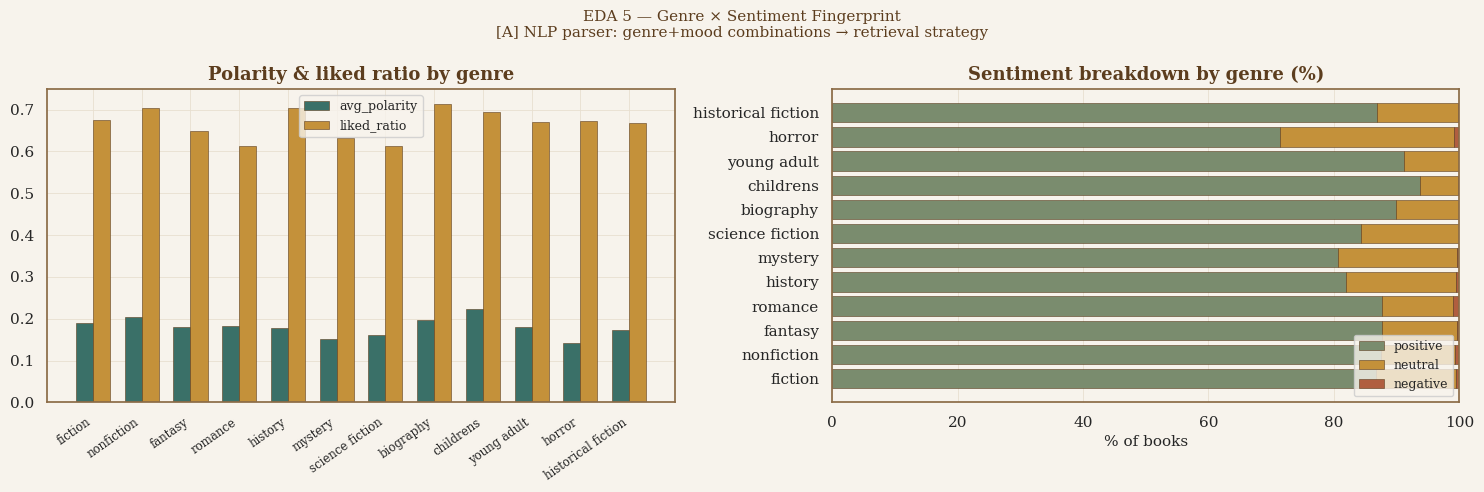

In [ ]:
# EDA 5: Genre × sentiment fingerprint matrix

# Use genre_clean (multi-label) — more granular than genre_primary
TOP_GENRES = [
    "fiction","nonfiction","fantasy","romance","history",
    "mystery","science fiction","biography","childrens","young adult",
    "horror","historical fiction"
]
rows = []
for g in TOP_GENRES:
    sub = reviews[reviews["genre_clean"].str.contains(g, na=False)]
    rows.append({
        "genre":       g,
        "n":           len(sub),
        "avg_polarity":sub["avg_polarity"].mean(),
        "liked_ratio": sub["liked_ratio"].mean(),
        "avg_rating":  sub["avg_rating"].mean(),
        "pct_positive":(sub["dominant_sentiment"]=="positive").mean()*100,
        "pct_neutral": (sub["dominant_sentiment"]=="neutral").mean()*100,
        "pct_negative":(sub["dominant_sentiment"]=="negative").mean()*100,
    })
gdf = pd.DataFrame(rows).set_index("genre").round(3)
print(gdf.to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    "EDA 5 — Genre × Sentiment Fingerprint\n"
    "[A] NLP parser: genre+mood combinations → retrieval strategy",
    fontsize=11, color=C["brown"]
)

x, w = np.arange(len(gdf)), 0.35
axes[0].bar(x - w/2, gdf["avg_polarity"], w, label="avg_polarity",
            color=C["teal"], edgecolor=C["brown"], linewidth=0.4)
axes[0].bar(x + w/2, gdf["liked_ratio"],  w, label="liked_ratio",
            color=C["gold"], edgecolor=C["brown"], linewidth=0.4)
axes[0].set_xticks(x)
axes[0].set_xticklabels(gdf.index, rotation=35, ha="right", fontsize=8.5)
axes[0].set_title("Polarity & liked ratio by genre")
axes[0].legend(fontsize=9)
axes[0].set_facecolor(C["cream"])

# stacked sentiment %
axes[1].barh(gdf.index, gdf["pct_positive"],
             color=C["sage"], edgecolor=C["brown"], linewidth=0.4, label="positive")
axes[1].barh(gdf.index, gdf["pct_neutral"],
             left=gdf["pct_positive"],
             color=C["gold"], edgecolor=C["brown"], linewidth=0.4, label="neutral")
axes[1].barh(gdf.index, gdf["pct_negative"],
             left=gdf["pct_positive"]+gdf["pct_neutral"],
             color=C["terra"], edgecolor=C["brown"], linewidth=0.4, label="negative")
axes[1].set_xlabel("% of books")
axes[1].set_title("Sentiment breakdown by genre (%)")
axes[1].legend(fontsize=9, loc="lower right")
axes[1].set_facecolor(C["cream"])

plt.tight_layout()

- Childrens (94%) and nonfiction (88%) = warmest genres by positivity
- Horror: despite its name, 73%+ reviews are positive — readers
    enjoy the experience. "Scary horror" needs avg_polarity < 0.10,
    not dominant_sentiment = negative
- Historical fiction and mystery have the lowest liked_ratio (~0.62–0.67)
- Most polarising genres; semantic re-ranking matters more here
- Science fiction low liked_ratio (0.62) — niche, critical audiences

=> Genre + mood retrieval strategy table:

      "cozy mystery"         → mystery  + avg_polarity > 0.20
      "grimdark fantasy"     → fantasy  + avg_polarity < 0.10
      "feel-good romance"    → romance  + liked_ratio > 0.75
      "psychological horror" → horror   + avg_polarity < 0.10
      "inspiring biography"  → biography + sentiment = positive
      "dark YA"              → young adult + sentiment IN (neutral, negative)

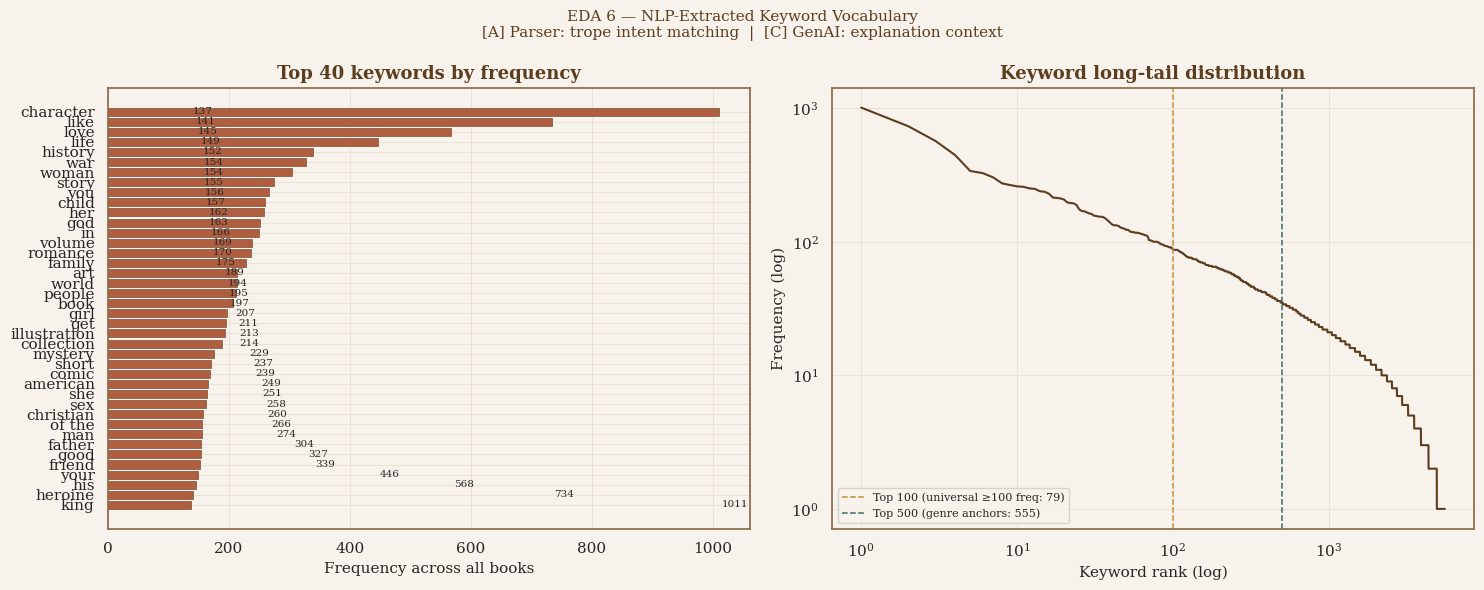

In [ ]:
# EDA 6: Top keywords — trope vocabulary

kw = Counter()
for row in reviews["top_keywords"]:
    for k in str(row).split(","):
        kw[k.strip().lower()] += 1

kw_df = pd.DataFrame(kw.most_common(40), columns=["keyword","count"])

# Classify by frequency tier
universal     = [k for k,v in kw.most_common() if v >= 100]
genre_anchor  = [k for k,v in kw.most_common() if 30 <= v < 100]
rare          = [k for k,v in kw.most_common() if v < 30]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    "EDA 6 — NLP-Extracted Keyword Vocabulary\n"
    "[A] Parser: trope intent matching  |  [C] GenAI: explanation context",
    fontsize=11, color=C["brown"]
)

axes[0].barh(kw_df["keyword"][::-1], kw_df["count"][::-1],
             color=C["terra"], edgecolor=C["brown"], linewidth=0.4)
axes[0].set_xlabel("Frequency across all books")
axes[0].set_title("Top 40 keywords by frequency")
axes[0].set_facecolor(C["cream"])
for i, row in kw_df.iloc[::-1].iterrows():
    axes[0].text(row["count"]+4, kw_df.index.get_loc(i),
                 str(row["count"]), va="center", fontsize=7.5)

# long-tail curve
all_counts = sorted(kw.values(), reverse=True)
axes[1].plot(range(1, len(all_counts)+1), all_counts,
             color=C["brown"], linewidth=1.5)
axes[1].axvline(100, color=C["gold"],  linestyle="--",
                linewidth=1.1, label=f"Top 100 (universal ≥100 freq: {len(universal)})")
axes[1].axvline(500, color=C["teal"], linestyle="--",
                linewidth=1.1, label=f"Top 500 (genre anchors: {len(genre_anchor)})")
axes[1].set_yscale("log")
axes[1].set_xscale("log")
axes[1].set_xlabel("Keyword rank (log)")
axes[1].set_ylabel("Frequency (log)")
axes[1].set_title("Keyword long-tail distribution")
axes[1].legend(fontsize=8)
axes[1].set_facecolor(C["cream"])

plt.tight_layout()

Total unique keywords: 5,533 across books
- Universal keywords (freq ≥ 100): 62  → 1.1%
- Genre anchors   (freq 30–99): 528 → 9.5%
- Rare / book-specific (<30): 4,884 → 89.4%

[A] NLP parser — two-level trope taxonomy
- Only 590 of 5,533 keywords (10.6%) are reusable for query matching. The other 89.3% are too rare or are noise
- Universal trope anchors (≥100): character, love, life, war, story,
    woman, family, mystery, romance — these power broad cross-genre matching.
- Noise keywords to FILTER before indexing: 'you', 'in', 'her', 'she',
    'his', 'like', 'get', 'of the' — stop-words that leaked through NLP.

[C] Generative AI — explanation generation
-  top_keywords per book are the context input to the LLM explanation prompt:
      "This book matches your query for '{{user_query}}' because its
       key themes are: {{top_keywords}}. Specifically..."
- The LLM should be instructed to use the book's actual keywords,
    not hallucinate themes — grounding explanations in extracted keywords
    improves factual accuracy and user trust.

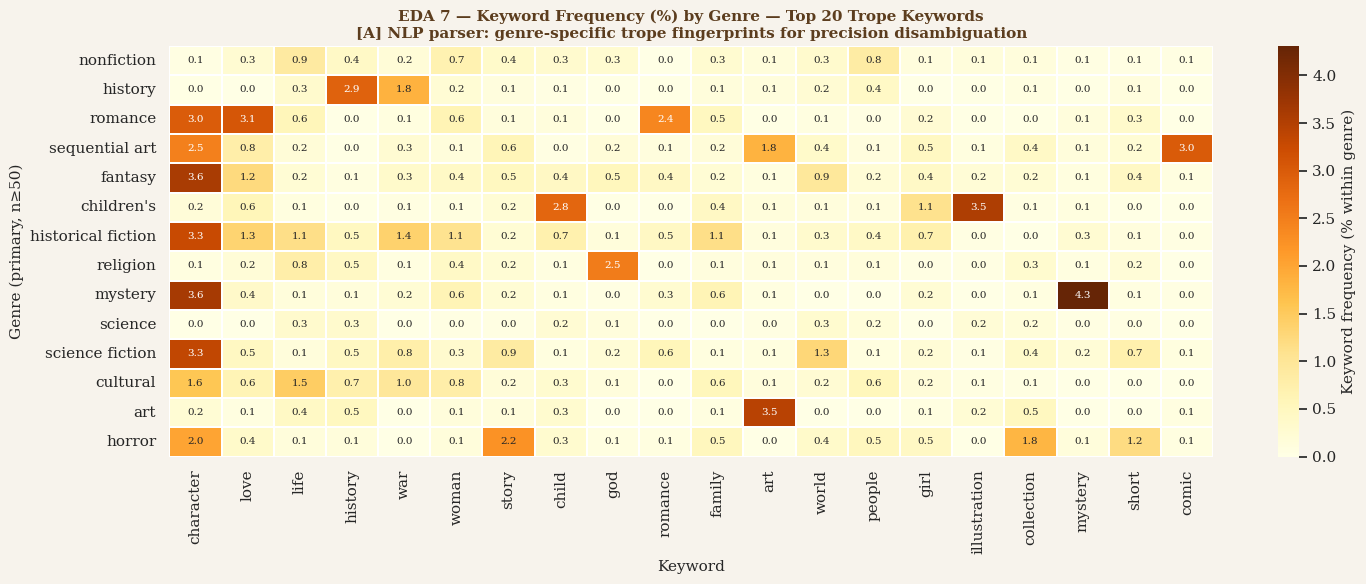

In [ ]:
# EDA 7: Keyword profiles per genre

# Use genre_primary (cleaner single-label) for genre-keyword profiles
# Filter to genres with ≥50 books for statistical stability
primary_counts = reviews["genre_primary"].value_counts()
stable_genres  = primary_counts[primary_counts >= 50].index.tolist()
stable_genres  = stable_genres[:14]  # top 14 for readable heatmap

genre_kw = {}
for genre in stable_genres:
    sub = reviews[reviews["genre_primary"] == genre]
    c   = Counter()
    for row in sub["top_keywords"]:
        for k in str(row).split(","):
            k = k.strip().lower()
            if k not in {"you","in","her","she","his","like","get",
                         "of the","i","it","is","to","a","the","and",
                         "or","as","that","with","for","from","at",
                         "your","we","all","be","this","there","this book"}:
                c[k] += 1
    genre_kw[genre] = c

# Top 20 meaningful universal keywords (stop-words filtered)
top_kw_clean = [k for k,v in kw.most_common(300)
                if k not in {"you","in","her","she","his","like","get",
                             "of the","i","it","is","to","a","the","and",
                             "or","as","that","with","for","from","at",
                             "your","we","all","be","this","there","this book",
                             "volume","book"}][:20]

heat = []
for genre in stable_genres:
    total = sum(genre_kw[genre].values()) or 1
    heat.append({k: genre_kw[genre].get(k, 0) / total * 100
                 for k in top_kw_clean})
heat_df = pd.DataFrame(heat, index=stable_genres)

fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(heat_df.round(2), cmap="YlOrBr", ax=ax, annot=True,
            fmt=".1f", linewidths=0.3, annot_kws={"size": 7.5},
            cbar_kws={"label": "Keyword frequency (% within genre)"})
ax.set_title(
    "EDA 7 — Keyword Frequency (%) by Genre — Top 20 Trope Keywords\n"
    "[A] NLP parser: genre-specific trope fingerprints for precision disambiguation",
    fontsize=11, color=C["brown"], fontweight="bold"
)
ax.set_xlabel("Keyword")
ax.set_ylabel("Genre (primary, n≥50)")
ax.set_facecolor(C["cream"])
plt.tight_layout()

- 'character' dominates romance and fantasy — character-driven query
    cues ("morally grey character") are strongest in these two genres
- 'war'+'history' concentrate in history/military — strong genre signal.
- 'love'+'heroine'+'hero' concentrate in romance — romance-specific tropes
    are well-separated from other genres
- 'story'+'collection' concentrate in short stories — useful for
    "anthology" or "short story collection" query detection

=>  Parser disambiguation rule:
    When a user query keyword matches a column in this heatmap, the
    genre with the highest row % for that keyword gets a soft boost
    (e.g. +10% to candidate pool) before the semantic re-ranker runs


  Top 10 books by retrieval score:
                                                                title  avg_rating  liked_ratio  retrieval_score dominant_sentiment
      best karate: kata: bassai, kanku v.6: kata: bassai, kanku vol 6       5.000          1.0         0.950000           positive
                                                     kithbook: sluagh       5.000          1.0         0.937692           positive
                                                  memoirs of a mother       5.000          1.0         0.930000           positive
redesign your life: using numerology to create the wildly optimal you       5.000          1.0         0.919231           positive
                                               yehudi menuhin: a life       5.000          1.0         0.914615           positive
                                        the magic of the minimum dose       5.000          1.0         0.913077           positive
                      pulp fashion: the art of 

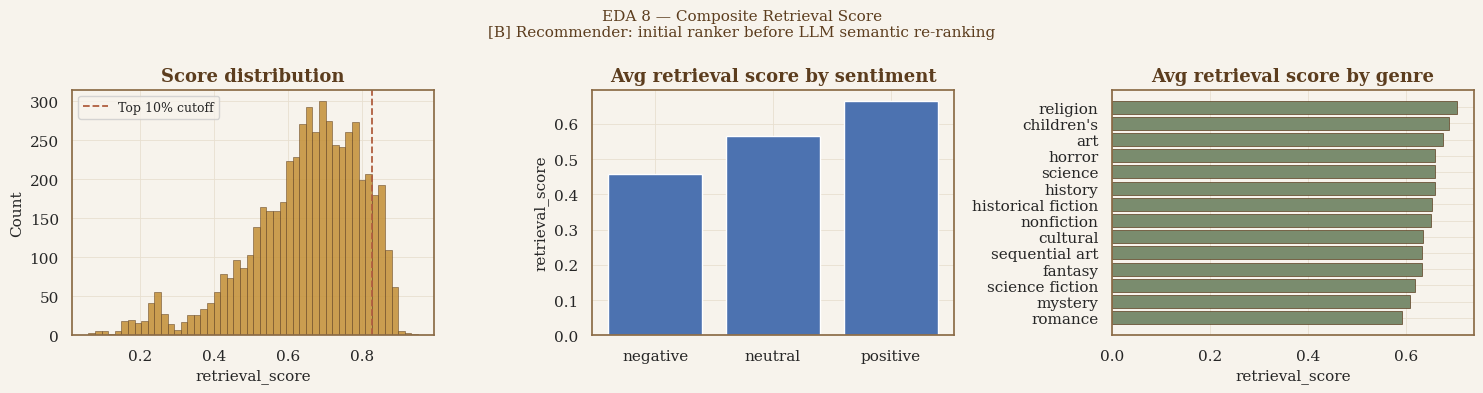

In [ ]:
# EDA 8: Composite retrieval score

def minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

reviews["s_liked"]    = minmax(reviews["liked_ratio"])
reviews["s_rating"]   = minmax(reviews["avg_rating"])
reviews["s_polarity"] = minmax(reviews["avg_polarity"])
reviews["s_reviews"]  = minmax(np.log1p(reviews["review_count"]))

# Weights justified by EDA 2 correlation strengths:
#   liked_ratio: primary (r=0.886 with avg_rating), highest collaborative signal
#   avg_rating:  secondary quality score
#   avg_polarity: independent NLP quality proxy, essential for cold-start
#   log(review_count): confidence weight only, tiny — avoids popular-book bias
reviews["retrieval_score"] = (
    0.45 * reviews["s_liked"]    +
    0.30 * reviews["s_rating"]   +
    0.20 * reviews["s_polarity"] +
    0.05 * reviews["s_reviews"]
)

top10 = (reviews[["title","author_clean","genre_primary","avg_rating",
                   "liked_ratio","avg_polarity","review_count",
                   "retrieval_score","dominant_sentiment","top_keywords"]]
         .sort_values("retrieval_score", ascending=False).head(10))
print("\n  Top 10 books by retrieval score:")
print(top10[["title","avg_rating","liked_ratio",
             "retrieval_score","dominant_sentiment"]].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(
    "EDA 8 — Composite Retrieval Score\n"
    "[B] Recommender: initial ranker before LLM semantic re-ranking",
    fontsize=11, color=C["brown"]
)

# distribution
axes[0].hist(reviews["retrieval_score"], bins=50, color=C["gold"],
             edgecolor=C["brown"], linewidth=0.4, alpha=0.88)
axes[0].axvline(reviews["retrieval_score"].quantile(0.90), color=C["terra"],
                linestyle="--", linewidth=1.3, label="Top 10% cutoff")
axes[0].set_xlabel("retrieval_score")
axes[0].set_ylabel("Count")
axes[0].set_title("Score distribution")
axes[0].legend(fontsize=9)

# score by sentiment
sent_score = reviews.groupby("dominant_sentiment")["retrieval_score"].mean()
axes[1].bar(sent_score.index, sent_score.values,
            color=[SENT_PAL[s] for s in sent_score.index],
            edgecolor=C["brown"], linewidth=0.5)
axes[1].set_title("Avg retrieval score by sentiment")
axes[1].set_ylabel("retrieval_score")
bars = axes[1].bar(sent_score.index, sent_score.values)

# score by genre_primary (top 12 stable genres)
gs_score = (reviews[reviews["genre_primary"].isin(stable_genres)]
            .groupby("genre_primary")["retrieval_score"].mean()
            .sort_values())
axes[2].barh(gs_score.index, gs_score.values,
             color=C["sage"], edgecolor=C["brown"], linewidth=0.5)
axes[2].set_title("Avg retrieval score by genre")
axes[2].set_xlabel("retrieval_score")

for ax in axes:
    ax.set_facecolor(C["cream"])
plt.tight_layout()

The retrieval score integrates multiple signals, including popularity, rating quality, and sentiment analysis. Books with positive sentiment tend to receive significantly higher scores, indicating that review sentiment is an important indicator of perceived book quality. While genre differences exist, the score distribution remains relatively balanced across categories, ensuring that the recommendation system does not strongly bias toward a specific genre

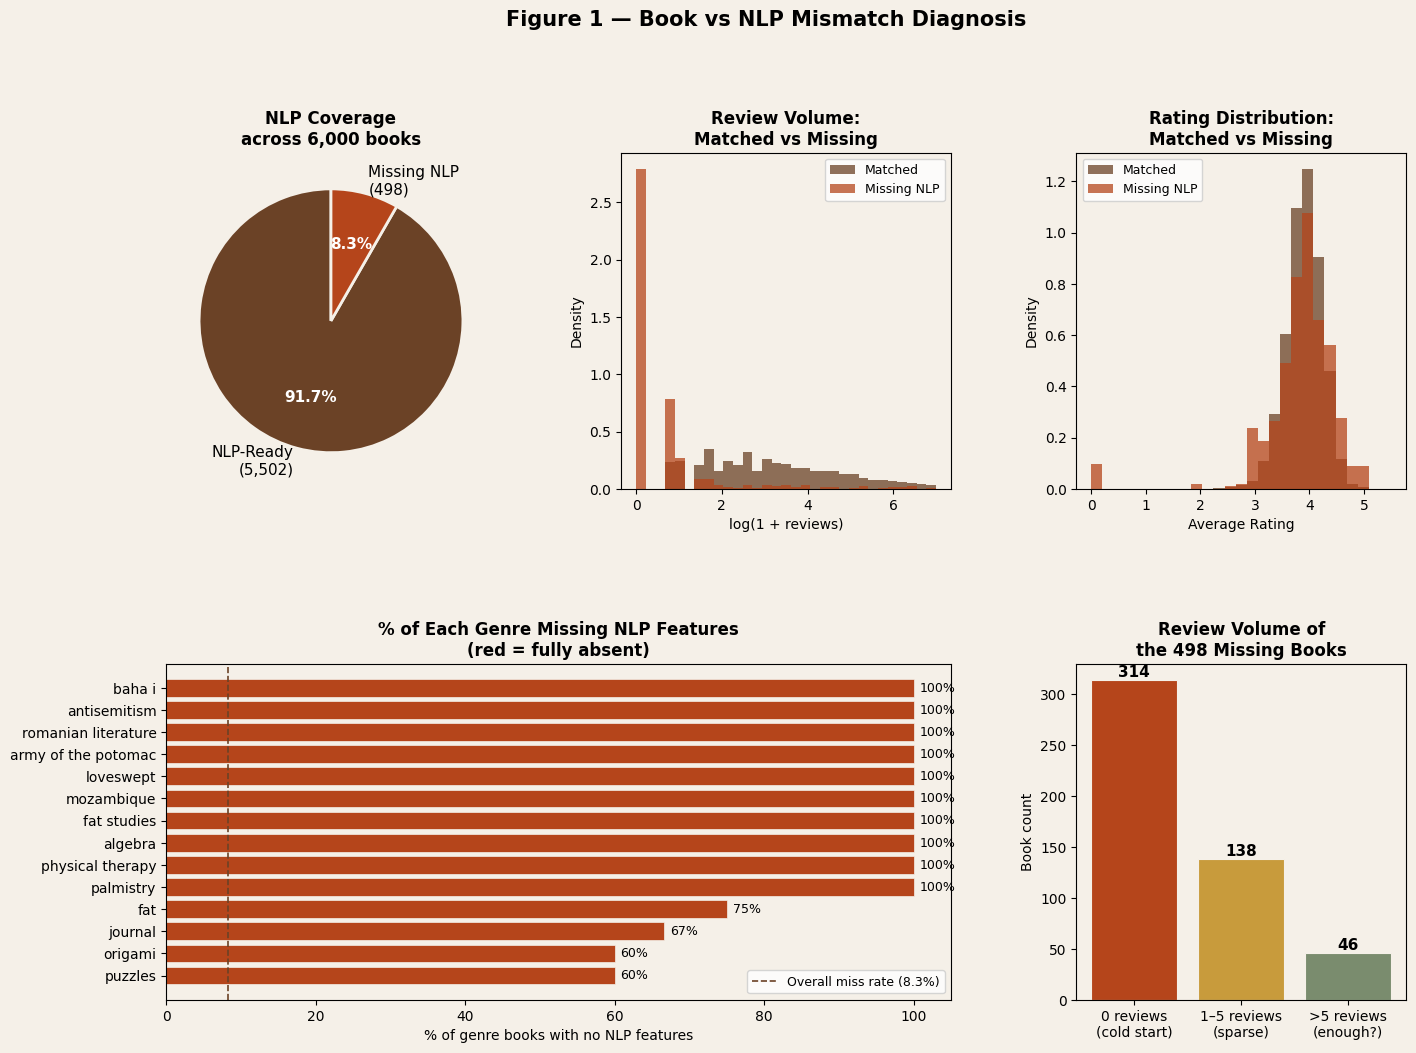

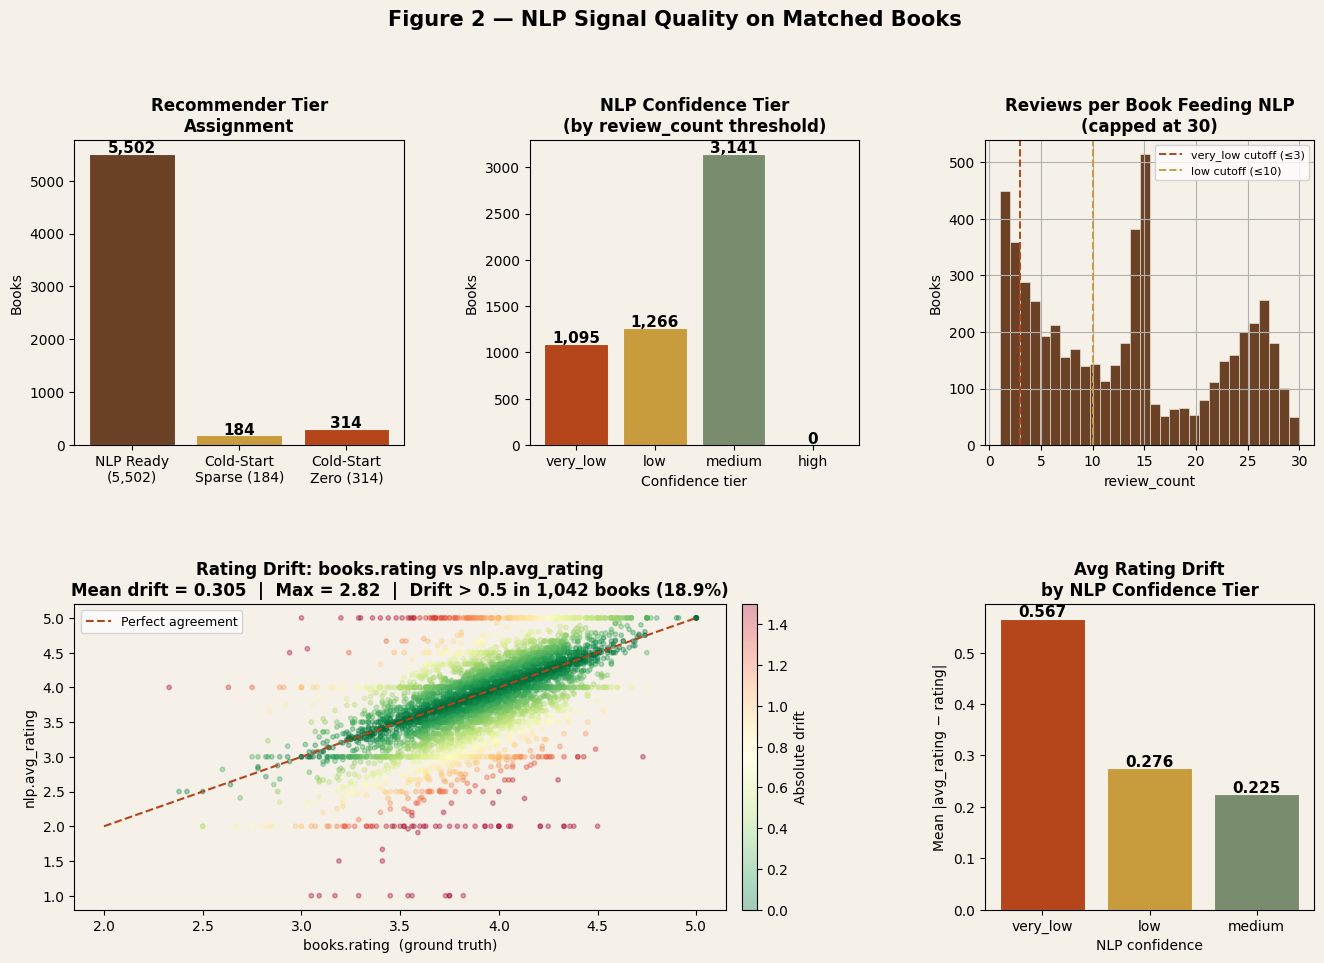

In [3]:
# Mismatch Problem
# 1. Prep
shared_cols   = sorted(set(nlp.columns) & set(books.columns) - {'book_id'})
nlp_ids       = set(nlp['book_id'])
books_ids     = set(books['book_id'])
matched       = nlp_ids & books_ids
books_only    = books_ids - nlp_ids

missing       = books[books['book_id'].isin(books_only)].copy()
matched_books = books[books['book_id'].isin(matched)].copy()

df = books.merge(nlp.drop(columns=shared_cols), on='book_id', how='left')
df['has_nlp'] = df['review_count'].notna()

def assign_tier(row):
    if not row['has_nlp']:
        return 'cold_start_zero' if row['reviews'] == 0 else 'cold_start_sparse'
    return 'nlp_ready'

df['recommender_tier'] = df.apply(assign_tier, axis=1)

nlp_ready = df[df['recommender_tier'] == 'nlp_ready'].copy()
nlp_ready['nlp_confidence'] = pd.cut(
    nlp_ready['review_count'],
    bins=[0, 3, 10, 50, 9999],
    labels=['very_low', 'low', 'medium', 'high']
)

g_miss = missing['genre_clean'].str.split('|').explode().str.strip().value_counts()
g_all  = books['genre_clean'].str.split('|').explode().str.strip().value_counts()
g_rate = (g_miss / g_all * 100).dropna().sort_values(ascending=False).head(14)

drift = (nlp_ready['avg_rating'] - nlp_ready['rating']).abs()

# Colour palette
BROWN = '#6B4226'; GOLD = '#C89B3C'; RUST = '#B5451B'
SAGE  = '#7A8C6E'; CREAM = '#F5F0E8'

# FIGURE 1 — Mismatch Diagnosis
fig1 = plt.figure(figsize=(16, 11))
fig1.patch.set_facecolor(CREAM)
gs1  = gridspec.GridSpec(2, 3, figure=fig1, hspace=0.52, wspace=0.38)

# 1a: Coverage pie
ax0 = fig1.add_subplot(gs1[0, 0])
ax0.set_facecolor(CREAM)
wedges, texts, autotexts = ax0.pie(
    [len(matched), len(books_only)],
    labels=[f'NLP-Ready\n({len(matched):,})', f'Missing NLP\n({len(books_only):,})'],
    colors=[BROWN, RUST],
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 11},
    wedgeprops={'edgecolor': CREAM, 'linewidth': 2}
)
for at in autotexts:
    at.set_color('white'); at.set_fontweight('bold')
ax0.set_title('NLP Coverage\nacross 6,000 books', fontweight='bold', fontsize=12, pad=8)

# 1b: Review volume — matched vs missing
ax1 = fig1.add_subplot(gs1[0, 1])
ax1.set_facecolor(CREAM)
bins = np.linspace(0, 7, 32)
ax1.hist(np.log1p(matched_books['reviews']), bins=bins, alpha=0.75,
         color=BROWN, label='Matched', density=True)
ax1.hist(np.log1p(missing['reviews']),       bins=bins, alpha=0.75,
         color=RUST,  label='Missing NLP', density=True)
ax1.set_xlabel('log(1 + reviews)', fontsize=10)
ax1.set_ylabel('Density', fontsize=10)
ax1.set_title('Review Volume:\nMatched vs Missing', fontweight='bold', fontsize=12)
ax1.legend(fontsize=9)

# 1c: Rating distribution — matched vs missing
ax2 = fig1.add_subplot(gs1[0, 2])
ax2.set_facecolor(CREAM)
bins2 = np.linspace(0, 5.5, 28)
ax2.hist(matched_books['rating'], bins=bins2, alpha=0.75,
         color=BROWN, label='Matched', density=True)
ax2.hist(missing['rating'],       bins=bins2, alpha=0.75,
         color=RUST,  label='Missing NLP', density=True)
ax2.set_xlabel('Average Rating', fontsize=10)
ax2.set_ylabel('Density', fontsize=10)
ax2.set_title('Rating Distribution:\nMatched vs Missing', fontweight='bold', fontsize=12)
ax2.legend(fontsize=9)

# 1d: Genre miss rate
ax3 = fig1.add_subplot(gs1[1, :2])
ax3.set_facecolor(CREAM)
bar_colors = [RUST if v > 50 else GOLD for v in g_rate.values]
bars = ax3.barh(g_rate.index, g_rate.values,
                color=bar_colors, edgecolor=CREAM, linewidth=0.5)
ax3.set_title('% of Each Genre Missing NLP Features\n(red = fully absent)',
              fontweight='bold', fontsize=12)
ax3.set_xlabel('% of genre books with no NLP features', fontsize=10)
ax3.axvline(8.3, color=BROWN, linestyle='--', linewidth=1.2,
            label=f'Overall miss rate (8.3%)')
ax3.legend(fontsize=9)
for bar in bars:
    ax3.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
             f'{bar.get_width():.0f}%', va='center', fontsize=9)
ax3.invert_yaxis()

# 1e: Missing 498 — review breakdown
ax4 = fig1.add_subplot(gs1[1, 2])
ax4.set_facecolor(CREAM)
r0   = (missing['reviews'] == 0).sum()
r1_5 = missing['reviews'].between(1, 5).sum()
r5p  = (missing['reviews'] > 5).sum()
cats = ['0 reviews\n(cold start)', '1–5 reviews\n(sparse)', '>5 reviews\n(enough?)']
vals = [r0, r1_5, r5p]
b4   = ax4.bar(cats, vals, color=[RUST, GOLD, SAGE], edgecolor=CREAM, linewidth=0.8)
ax4.set_title('Review Volume of\nthe 498 Missing Books', fontweight='bold', fontsize=12)
ax4.set_ylabel('Book count', fontsize=10)
for bar, v in zip(b4, vals):
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
             str(v), ha='center', fontsize=11, fontweight='bold')

fig1.suptitle('Figure 1 — Book vs NLP Mismatch Diagnosis',
              fontsize=15, fontweight='bold', y=1.01)
plt.show()

# FIGURE 2 — NLP Signal Quality on Matched Books
fig2 = plt.figure(figsize=(16, 10))
fig2.patch.set_facecolor(CREAM)
gs2  = gridspec.GridSpec(2, 3, figure=fig2, hspace=0.52, wspace=0.38)

# 2a: Recommender tier bar
ax5 = fig2.add_subplot(gs2[0, 0])
ax5.set_facecolor(CREAM)
tier_counts = df['recommender_tier'].value_counts()
tier_order  = ['nlp_ready', 'cold_start_sparse', 'cold_start_zero']
tier_labels = [f'NLP Ready\n({tier_counts.get("nlp_ready",0):,})',
               f'Cold-Start\nSparse ({tier_counts.get("cold_start_sparse",0):,})',
               f'Cold-Start\nZero ({tier_counts.get("cold_start_zero",0):,})']
tier_vals   = [tier_counts.get(t, 0) for t in tier_order]
b5 = ax5.bar(tier_labels, tier_vals,
             color=[BROWN, GOLD, RUST], edgecolor=CREAM, linewidth=0.8)
ax5.set_title('Recommender Tier\nAssignment', fontweight='bold', fontsize=12)
ax5.set_ylabel('Books', fontsize=10)
for bar, v in zip(b5, tier_vals):
    ax5.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
             f'{v:,}', ha='center', fontsize=11, fontweight='bold')

# 2b: NLP confidence tier
ax6 = fig2.add_subplot(gs2[0, 1])
ax6.set_facecolor(CREAM)
conf_counts = nlp_ready['nlp_confidence'].value_counts().sort_index()
b6 = ax6.bar(conf_counts.index, conf_counts.values,
             color=[RUST, GOLD, SAGE, BROWN][:len(conf_counts)],
             edgecolor=CREAM, linewidth=0.8)
ax6.set_title('NLP Confidence Tier\n(by review_count threshold)',
              fontweight='bold', fontsize=12)
ax6.set_ylabel('Books', fontsize=10)
ax6.set_xlabel('Confidence tier', fontsize=10)
for bar, v in zip(b6, conf_counts.values):
    ax6.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
             f'{v:,}', ha='center', fontsize=11, fontweight='bold')

# 2c: review_count histogram
ax7 = fig2.add_subplot(gs2[0, 2])
ax7.set_facecolor(CREAM)
nlp_ready['review_count'].clip(upper=30).hist(
    bins=30, ax=ax7, color=BROWN, edgecolor=CREAM, linewidth=0.4
)
ax7.axvline(3,  color=RUST, linestyle='--', linewidth=1.4, label='very_low cutoff (≤3)')
ax7.axvline(10, color=GOLD, linestyle='--', linewidth=1.4, label='low cutoff (≤10)')
ax7.set_title('Reviews per Book Feeding NLP\n(capped at 30)',
              fontweight='bold', fontsize=12)
ax7.set_xlabel('review_count', fontsize=10)
ax7.set_ylabel('Books', fontsize=10)
ax7.legend(fontsize=8)

# 2d: Rating drift scatter
ax8 = fig2.add_subplot(gs2[1, :2])
ax8.set_facecolor(CREAM)
sc = ax8.scatter(
    nlp_ready['rating'], nlp_ready['avg_rating'],
    c=drift, cmap='RdYlGn_r', alpha=0.35, s=10, vmin=0, vmax=1.5
)
ax8.plot([2, 5], [2, 5], color=RUST, linewidth=1.5,
         linestyle='--', label='Perfect agreement')
plt.colorbar(sc, ax=ax8, label='Absolute drift', pad=0.02)
ax8.set_xlabel('books.rating  (ground truth)', fontsize=10)
ax8.set_ylabel('nlp.avg_rating', fontsize=10)
ax8.set_title(
    f'Rating Drift: books.rating vs nlp.avg_rating\n'
    f'Mean drift = {drift.mean():.3f}  |  Max = {drift.max():.2f}  |  '
    f'Drift > 0.5 in {(drift > 0.5).sum():,} books ({(drift > 0.5).mean():.1%})',
    fontweight='bold', fontsize=12
)
ax8.legend(fontsize=9)

# 2e: Drift by confidence tier
ax9 = fig2.add_subplot(gs2[1, 2])
ax9.set_facecolor(CREAM)
drift_df = nlp_ready.copy()
drift_df['drift'] = drift
drift_by_conf = drift_df.groupby('nlp_confidence', observed=True)['drift'].mean()
b9 = ax9.bar(drift_by_conf.index, drift_by_conf.values,
             color=[RUST, GOLD, SAGE], edgecolor=CREAM, linewidth=0.8)
ax9.set_title('Avg Rating Drift\nby NLP Confidence Tier', fontweight='bold', fontsize=12)
ax9.set_ylabel('Mean |avg_rating − rating|', fontsize=10)
ax9.set_xlabel('NLP confidence', fontsize=10)
for bar, v in zip(b9, drift_by_conf.values):
    ax9.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
             f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

fig2.suptitle('Figure 2 — NLP Signal Quality on Matched Books',
              fontsize=15, fontweight='bold', y=1.01)
plt.show()

C. EDA FOR USER'S INTERACTION

In [ ]:
import pandas as pd

df = pd.read_csv('/content/interaction.csv')

print(df.shape)
df.head()
df.info()

(449691, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 449691 entries, 0 to 449690
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   interaction_id  449691 non-null  object 
 1   user_id         449691 non-null  int64  
 2   book_id         416048 non-null  float64
 3   review          449691 non-null  int64  
 4   rating          449691 non-null  int64  
 5   save            449691 non-null  int64  
 6   click           449691 non-null  int64  
 7   search          449691 non-null  object 
 8   purchase        449691 non-null  int64  
 9   share           449691 non-null  int64  
 10  timestamp       449691 non-null  object 
 11  source          449691 non-null  object 
 12  month           449691 non-null  object 
dtypes: float64(1), int64(7), object(5)
memory usage: 44.6+ MB


In [ ]:
# load file mới
rating_norm_df = pd.read_csv('/content/book_nlp_features.csv', engine='python', on_bad_lines='skip')

print(rating_norm_df.head())

   book_id                                              title  \
0       11  certain to win: the strategy of john boyd, app...   
1       12  the zigzag principle: the goal setting strateg...   
2       13  chancellorsville's forgotten front: the battle...   
3       25                       java concurrency in practice   
4       46  a dream foreclosed: black america and the figh...   

                                        author_clean     genre_primary  \
0                                      chet richards          business   
1                                  rich christiansen          business   
2                chris mackowski,kristopher d. white  military history   
3  brian goetz,tim peierls,joshua bloch,joseph bo...  computer science   
4  laura gottesdiener,clarence lusane,r. black,ja...        nonfiction   

                                         genre_clean  \
0  business|management|nonfiction|leadership|war|...   
1  business|entrepreneurship|self help|leadership...

In [ ]:
import pandas as pd

df = pd.read_csv('/content/interaction.csv')
review_df = pd.read_csv('/content/review_clean.csv', engine='python', on_bad_lines='skip')


df['norm_rating'] = (df['rating'] - df['rating'].min()) / (df['rating'].max() - df['rating'].min())

df_positive = df[df['rating'] > 0]

print(df_positive[['rating', 'norm_rating']].head(20))

      rating  norm_rating
2435       3          0.6
2437       4          0.8
2439       4          0.8
2448       2          0.4
2452       3          0.6
2457       3          0.6
2460       2          0.4
2474       5          1.0
2477       4          0.8
2478       3          0.6
2484       4          0.8
2487       5          1.0
2492       2          0.4
2496       4          0.8
2498       5          1.0
2499       3          0.6
2500       4          0.8
2503       4          0.8
2504       5          1.0
2506       4          0.8


In [ ]:
user_activity = df.groupby('user_id').size()

user_activity.describe()

,0
count,33643.000000
mean,13.366555
std,38.186211
min,5.000000
25%,6.000000
50%,8.000000
75%,9.000000
max,1655.000000


In [ ]:
book_popularity = df.groupby('book_id').size()

book_popularity.describe()

,0
count,6000.000000
mean,69.341333
std,48.914476
min,1.000000
25%,23.000000
50%,67.000000
75%,112.250000
max,183.000000


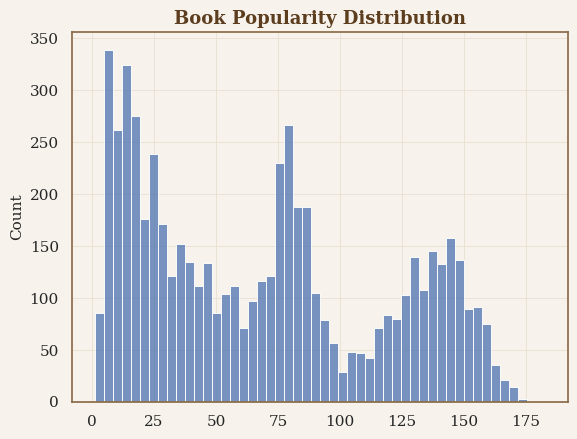

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(book_popularity, bins=50)
plt.title("Book Popularity Distribution")
plt.show()

The distribution of book popularity is highly skewed and forms clear tiers, with a large concentration of books in the low-interaction range (below 40), a moderate cluster in the mid-range (60–100), and a smaller but distinct group in the high-interaction range (~120–160+). This uneven structure indicates that only a limited number of books achieve high visibility, while the majority remain in the long tail with relatively low engagement.

This pattern reflects a strong popularity bias, where highly interacted books continue to accumulate more attention, reinforcing their dominance. In contrast, low-tier books struggle to gain exposure, even if they may be of comparable quality.

Impact:

* The concentration of interactions in the high tier (~120–160+) suggests that a small subset of books is driving a disproportionate share of user engagement, which can lead to over-reliance on a narrow content pool.
* The large volume of low-tier books (<40 interactions) represents untapped potential, but without intervention, these items are unlikely to surface, limiting catalog utilization and content ROI.
* Popularity bias can reduce recommendation diversity, leading to repetitive user experiences and potential engagement fatigue over time.
* Introducing mechanisms such as diversified ranking, exploration boosting, or long-tail promotion could help redistribute attention, improving both user discovery experience and overall platform value.

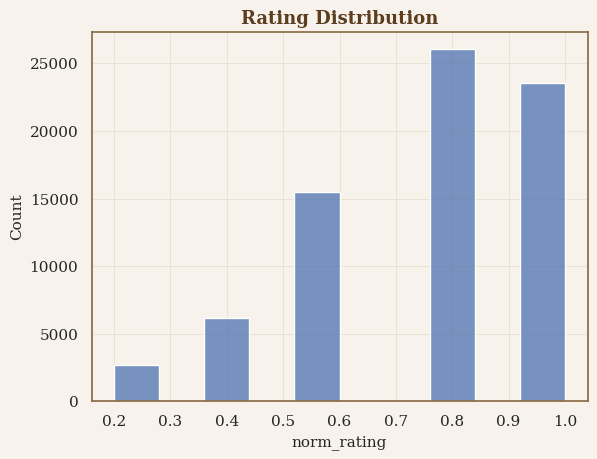

In [ ]:
# lọc bỏ rating = 0
df_filtered = df[df['norm_rating'] > 0]

# vẽ lại
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(df_filtered['norm_rating'], bins=10)
plt.title("Rating Distribution")
plt.show()

The rating distribution is heavily skewed toward the higher end, with most values concentrated between 0.6 and 1.0, indicating that users tend to give relatively positive ratings rather than using the full scale. Lower ratings are significantly underrepresented, suggesting a positivity bias in user feedback. This pattern implies that ratings may have limited discriminative power, as many items receive similarly high scores, making it harder to distinguish truly exceptional content from average ones. As a result, relying solely on ratings for recommendation could reduce effectiveness, and additional behavioral signals (e.g., interactions) are needed to better capture user preferences.

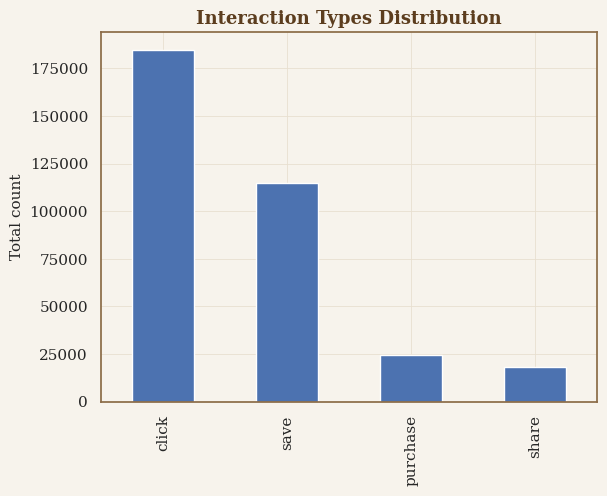

In [ ]:
interaction_cols = ['click', 'save', 'purchase', 'share']

interaction_sums = df[interaction_cols].sum()

interaction_sums.plot(kind='bar')
plt.title("Interaction Types Distribution")
plt.ylabel("Total count")
plt.show()

The rating distribution is heavily skewed toward the higher end, with most values concentrated between 0.6 and 1.0, indicating that users tend to give relatively positive ratings rather than using the full scale. Lower ratings are significantly underrepresented, suggesting a positivity bias in user feedback. This pattern implies that ratings may have limited discriminative power, as many items receive similarly high scores, making it harder to distinguish truly exceptional content from average ones. As a result, relying solely on ratings for recommendation could reduce effectiveness, and additional behavioral signals (e.g., interactions) are needed to better capture user preferences.

The chart shows that user behavior is heavily concentrated in low-commitment interactions such as clicks and saves, while higher-conversion actions like purchases and shares account for a much smaller proportion.

In [ ]:
df['interaction_score'] = (
    df['purchase'] * 0.35 +
    df['save'] * 0.25 +
    df['share'] * 0.20 +
    df['click'] * 0.10 +
    # Convert 'search' column to a numeric indicator (1 if a search term is present, 0 otherwise)
    # The original 'search' column contains string values, which caused the TypeError.
    (df['search'].apply(lambda x: 1 if x and isinstance(x, str) and x.strip() != '' else 0)) * 0.10
)

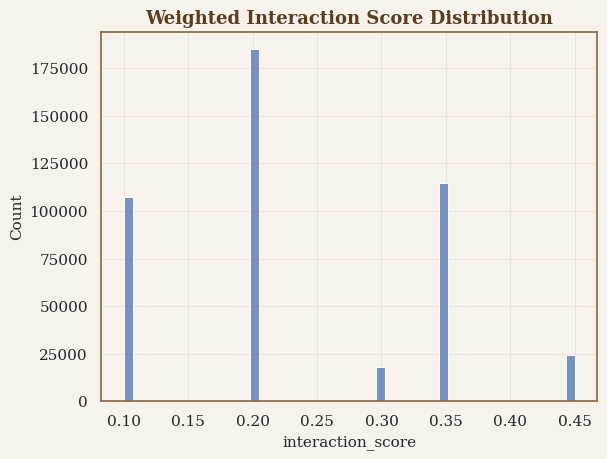

In [ ]:
sns.histplot(df['interaction_score'], bins=50)
plt.title("Weighted Interaction Score Distribution")
plt.show()

The relatively low visibility of the 0.25 (save-only) score suggests that saving rarely occurs as an isolated behavior. Instead, it is frequently combined with other actions such as clicks or searches, leading to higher composite scores (e.g., 0.35 or 0.45). This reinforces the idea that “save” operates as a mid-funnel signal of intent, rather than a final engagement outcome. Users who save content are typically already engaged in a broader interaction journey, indicating a higher likelihood of progressing toward deeper actions.

The absence of a clear peak at 0.40 (share + click + search) suggests that sharing rarely occurs within limited interaction combinations. Instead, share is typically associated with more comprehensive engagement patterns, often accompanied by higher-value actions such as saving or purchasing.

Impact:

* Since save is embedded within multi-action behavior, it should be leveraged as a predictive signal for conversion rather than treated as a standalone KPI. Users who save are strong candidates for targeted nudges (e.g., reminders, personalized recommendations, limited-time offers).

* The combination patterns (e.g., click + save, search + save) can be used to build interaction sequences, enabling more accurate modeling of user journeys and improving recommendation timing.
* Optimizing transitions from save → purchase/share represents a high-impact opportunity, as users at this stage already demonstrate intent. Small improvements in this step can yield disproportionate gains in conversion rate and lifetime value.

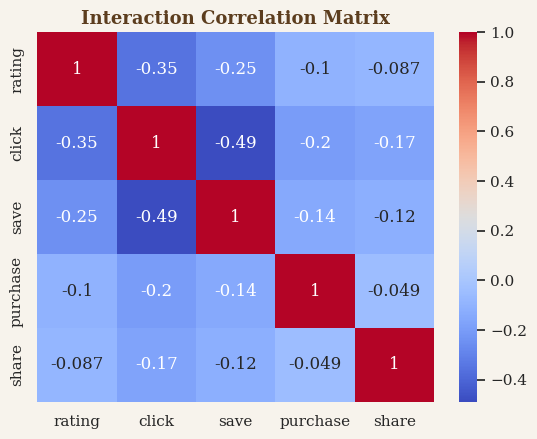

In [ ]:
corr = df[['rating', 'click', 'save', 'purchase', 'share']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Interaction Correlation Matrix")
plt.show()



*  As the number of clicks, saves, purchases, and shares increases, the average rating tends to slightly decrease → highly popular books attract more users, but broader exposure leads to more diverse opinions, lowering the overall average rating.


* Click ↔ Save (corr = -0.49) → users tend to either click to engage immediately or save for later, but rarely do both.
* Purchase shows little correlation with other behaviors → many users click and save but do not convert, suggesting that purchase decisions depend on other factors such as how compelling the content is or whether it matches specific preferences (e.g., desired tropes).






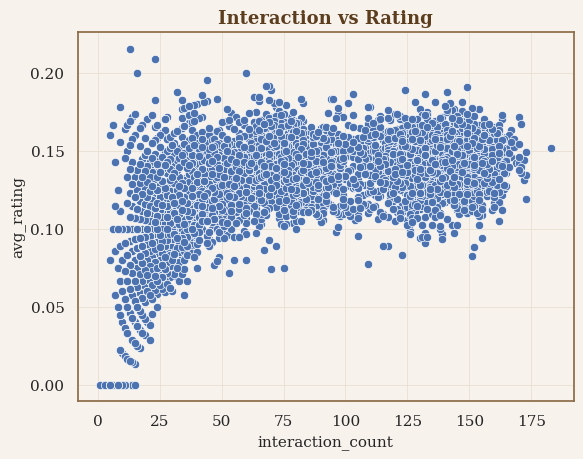

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define book_stats (moved from a later cell to fix NameError)
book_stats = df.groupby('book_id').agg({
    'norm_rating': ['mean', 'count']
})
book_stats.columns = ['avg_rating', 'interaction_count']
book_stats = book_stats.reset_index()

plt.figure()
sns.scatterplot(
    data=book_stats,
    x='interaction_count',
    y='avg_rating'
)
plt.title("Interaction vs Rating")
plt.show()

The scatter plot shows no strong positive relationship between interaction count and average rating. For books with low interactions (<30), ratings are highly dispersed, ranging from near 0 up to ~0.20, indicating unstable and less reliable evaluations due to limited feedback. As interaction count increases (especially above ~80–100), ratings begin to stabilize and cluster within a narrower band of approximately 0.12–0.16, suggesting more consistent and reliable user evaluations.

However, despite this increased stability, higher interaction levels do not lead to higher ratings. Highly interacted books (120–170+ interactions) still maintain similar average ratings to mid-tier books, reinforcing that popularity improves rating reliability, not rating quality.

Impact:

* Low-interaction books suffer from high uncertainty, making it difficult to assess true quality → requires exploration or boosting strategies.
* High-interaction books provide more trustworthy signals, making them safer for recommendations but not necessarily better in quality.
* Relying solely on popularity may lead to safe but not optimal recommendations, highlighting the need to combine interaction data with other signals (e.g., personalization, sentiment, diversity).

In [ ]:
user_stats = df.groupby('user_id')['norm_rating'].agg(['mean', 'std']).reset_index()

print(user_stats.head())

   user_id      mean       std
0        0  0.152381  0.347281
1        1  0.150000  0.325279
2        2  0.125000  0.353553
3        3  0.133333  0.305505
4        4  0.077778  0.195706


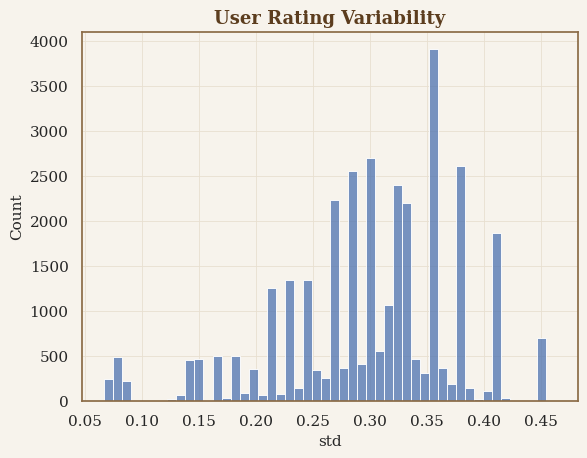

In [ ]:
plt.figure()
sns.histplot(user_stats['std'], bins=50)
plt.title("User Rating Variability")
plt.show()

The distribution of user rating standard deviation is concentrated primarily in the 0.25–0.35 range, with a peak around ~0.30–0.33, indicating that most users exhibit moderate variability in their ratings. A smaller portion of users falls below 0.15 (highly consistent raters), while another smaller group exceeds 0.40 (highly inconsistent or exploratory users). This suggests that the majority of users do not rate uniformly but instead adjust their ratings depending on the content, reflecting diverse preferences and active exploration behavior.

Impact:

* The dominance of moderate-variance users (~0.30) implies that recommendation systems should prioritize personalization and diversity, as users are open to different types of content rather than sticking to a fixed taste profile.
* The presence of low-variance users (<0.15) suggests a segment that prefers consistent, niche-aligned recommendations, which can be leveraged for retention through highly tailored suggestions.
* The high-variance group (>0.40) represents exploratory users who are more likely to engage with new or unexpected content, making them ideal targets for discovery features, new releases, and serendipitous recommendations.


In [ ]:
user_book_counts = df.groupby(['user_id', 'book_id']).size().reset_index(name='count')

re_read = user_book_counts[user_book_counts['count'] > 1]

print(re_read.head())
print("Number of repeated interactions:", len(re_read))

   user_id  book_id  count
0        0   6665.0      3
2        0   9315.0      7
4        0  20020.0      6
5        0  21567.0      8
6        0  38337.0      6
Number of repeated interactions: 73911


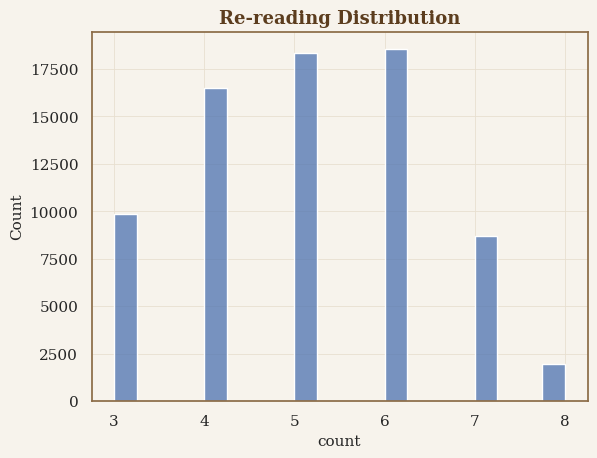

In [ ]:
plt.figure()
sns.histplot(re_read['count'], bins=20)
plt.title("Re-reading Distribution")
plt.show()

The distribution shows that re-reading behavior is concentrated around 4–6 times, with the highest frequency at 5–6, indicating that most users revisit content at a moderate level rather than excessively. Lower re-reading counts (e.g., 3 times) and higher counts (7–8 times) account for a noticeably smaller proportion, suggesting that both minimal engagement and strong habit formation are less common.

This pattern implies that users find content engaging enough to return, but not compelling enough to drive repeated, habitual re-consumption at a high frequency. In other words, the platform achieves consistent but not deeply sticky engagement.

Impact:

* The dominance of mid-level re-reading suggests an opportunity to increase content stickiness by introducing features such as personalized recommendations, sequel prompts, or “continue similar stories” nudges.
* The relatively small group of high re-readers (7–8) represents a valuable segment for loyalty-driven strategies (e.g., premium content, community features).
* Converting mid-level users (4–6) into high-frequency re-readers could significantly boost retention and lifetime value, as they are already partially engaged but not yet fully habituated.

In [ ]:
from itertools import combinations
from collections import Counter

user_books = df.groupby('user_id')['book_id'].apply(list)

pair_counts = Counter()

for books in user_books:
    for pair in combinations(set(books), 2):
        pair_counts[pair] += 1

print(pair_counts.most_common(10))

[((35532.0, 40047.0), 14), ((36381.0, 39974.0), 13), ((42369.0, 39718.0), 13), ((36381.0, 43078.0), 12), ((36037.0, 41075.0), 11), ((28298.0, 47355.0), 11), ((12814.0, 32112.0), 11), ((23873.0, 4442.0), 11), ((29378.0, 35532.0), 10), ((29378.0, 40047.0), 10)]


The analysis results show that there are pairs of books that are frequently read together by many users, reflecting latent relationships between books based on actual user behavior.

In [ ]:
num_users = df['user_id'].nunique()
num_books = df['book_id'].nunique()
num_interactions = len(df)

density = num_interactions / (num_users * num_books)

print("Users:", num_users)
print("Books:", num_books)
print("Interactions:", num_interactions)
print("Matrix density:", density)

Users: 33643
Books: 6000
Interactions: 449691
Matrix density: 0.0022277591177956783


In [ ]:
user_bias = df.groupby('user_id')['norm_rating'].mean().reset_index(name='avg_rating')

print(user_bias.head())
print(user_bias.describe())

   user_id  avg_rating
0        0    0.152381
1        1    0.150000
2        2    0.125000
3        3    0.133333
4        4    0.077778
           user_id    avg_rating
count  33643.00000  33643.000000
mean   16821.00000      0.117948
std     9712.04189      0.034861
min        0.00000      0.022222
25%     8410.50000      0.100000
50%    16821.00000      0.120000
75%    25231.50000      0.142857
max    33642.00000      0.250000


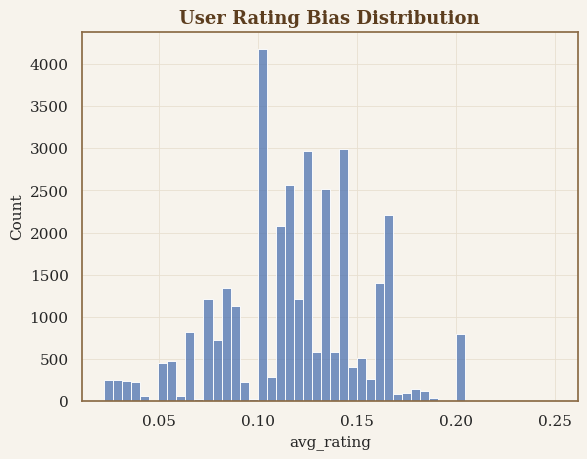

In [ ]:
plt.figure()
sns.histplot(user_bias['avg_rating'], bins=50)
plt.title("User Rating Bias Distribution")
plt.show()

The distribution of user rating bias (avg_rating) shows that most users are concentrated within a narrow mid-range, approximately 0.10–0.15, while only a small proportion of users exhibit very low or very high average ratings. This indicates that users tend to rate conservatively, avoiding extreme scores and favoring moderate evaluations.

This pattern suggests a central tendency bias, where users prefer giving “safe” ratings rather than expressing strong positive or negative opinions. As a result, rating signals may lack strong differentiation, making it more difficult to distinguish truly exceptional or poor-quality items based solely on average ratings.

In [ ]:
book_variance = df.groupby('book_id')['norm_rating'].std().reset_index(name='rating_std')

print(book_variance.head())

   book_id  rating_std
0     11.0    0.321985
1     12.0    0.338691
2     13.0    0.338609
3     25.0    0.364371
4     46.0    0.316718


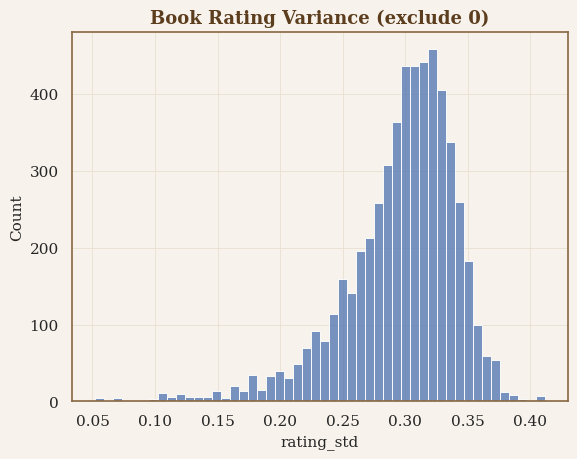

In [ ]:
# lọc bỏ std = 0
book_variance_filtered = book_variance[book_variance['rating_std'] > 0]

# vẽ lại
plt.figure()
sns.histplot(book_variance_filtered['rating_std'], bins=50)
plt.title("Book Rating Variance (exclude 0)")
plt.show()

The distribution of rating variance is strongly centered around a moderate range, approximately 0.28–0.32, with the highest density of books clustering near ~0.30. Only a small proportion of books fall into the lower variance range (<0.15) or the higher variance range (>0.35–0.40), indicating that extreme cases of very consistent or highly polarized ratings are relatively rare.

This pattern suggests that most books receive fairly consistent evaluations across users, with limited disagreement in perceived quality.

However, the lack of high-variance (polarizing) items also implies a potential limitation: the system may be missing content that drives strong emotional reactions or differentiated opinions, which are often key drivers of engagement, discussion, and discovery.

Business Implications:

* The dominance of mid-range variance (~0.30) indicates that ratings are reliable but not highly distinctive, which may reduce the system’s ability to clearly separate exceptional content from average items.
* The scarcity of high-variance books (>0.35) suggests a lack of polarizing or niche content, potentially limiting user engagement depth and viral potential.
* Introducing or promoting more diverse and distinctive content could increase variance, helping the system better capture user preferences and improve personalization.


In [ ]:
user_engagement = df.groupby('user_id').size()
user_satisfaction = df.groupby('user_id')['norm_rating'].mean()

user_profile = pd.concat([user_engagement, user_satisfaction], axis=1)
user_profile.columns = ['engagement', 'satisfaction']

print(user_profile.head())

         engagement  satisfaction
user_id                          
0                42      0.152381
1                32      0.150000
2                 8      0.125000
3                39      0.133333
4                18      0.077778


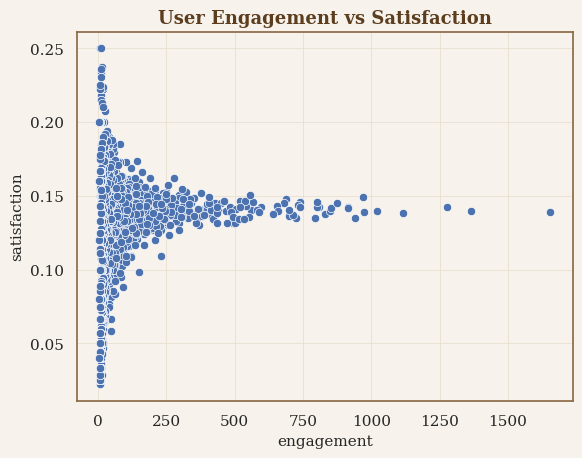

In [ ]:
plt.figure()
sns.scatterplot(
    data=user_profile,
    x='engagement',
    y='satisfaction'
)
plt.title("User Engagement vs Satisfaction")
plt.show()

The scatter plot indicates that there is no strong or linear relationship between user engagement and satisfaction. At low levels of engagement (roughly <100 interactions), satisfaction values are highly dispersed, ranging widely from ~0.02 up to ~0.25, which reflects a high degree of variability in user experience. This suggests that when users interact less, their satisfaction is unstable and heavily dependent on specific books, leading to both very positive and very negative experiences.

As engagement increases (around 100–500+ interactions), the dispersion of satisfaction begins to narrow, with most values clustering within a tighter band of approximately 0.12–0.16. At even higher engagement levels (>800–1000 interactions), satisfaction becomes even more stable, but it does not increase significantly.

This pattern suggests that higher engagement improves the reliability and predictability of user experience, rather than its quality.

Impact:

Low-engagement users represent a high-risk segment, as their satisfaction is unpredictable and can easily skew negative, it requires better onboarding, early-stage recommendations.

High-engagement users show stable but not increasing satisfaction. The lack of a positive correlation suggests that optimizing for engagement alone may not lead to better user experience so platforms should focus on quality of recommendations and personalization.

There is an opportunity to convert low-engagement users into more stable segments by improving early experiences, while simultaneously enhancing content differentiation to break the “moderate satisfaction plateau” among highly engaged users.

In [ ]:
book_stats = df.groupby('book_id').agg({
    'norm_rating': ['mean', 'count']
})

book_stats.columns = ['avg_rating', 'interaction_count']
book_stats = book_stats.reset_index()

# chia nhóm
book_stats['tier'] = pd.qcut(book_stats['interaction_count'], q=3, labels=['low', 'mid', 'high'])

print(book_stats.head())

   book_id  avg_rating  interaction_count  tier
0     11.0    0.136957                 92  high
1     12.0    0.153846                 65   mid
2     13.0    0.153846                 39   mid
3     25.0    0.169444                144  high
4     46.0    0.136000                 50   mid


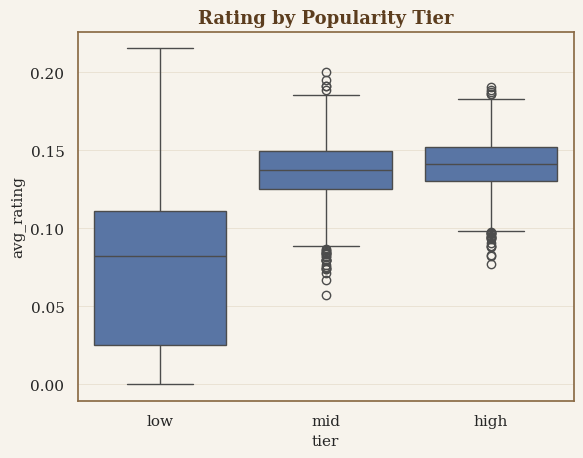

In [ ]:
plt.figure()
sns.boxplot(data=book_stats, x='tier', y='avg_rating')
plt.title("Rating by Popularity Tier")
plt.show()

The chart shows a clear difference in rating distribution across popularity tiers. Low-tier books exhibit a wide spread of ratings, from near 0 up to 0.22, indicating highly inconsistent quality with both very poor and very good titles. In contrast, mid- and high-tier books have ratings concentrated within a narrower range (from 0.12–0.15), reflecting more stable and consistent user evaluations. Although the median rating increases slightly from low, mid to high, the difference is minimal, suggesting that popular books are not significantly better, but simply more consistently rated.

Impact:

Low-tier books represent high-risk but high-opportunity content need exploration or boosting to uncover hidden gems.
High-tier books are safe choices for recommendation due to rating stability, but may lead to content homogeneity if overused.
The weak difference in median ratings reinforces that popularity doesn't mean quality, so relying solely on popularity can limit recommendation effectiveness.
A balanced strategy combining exploration (low-tier) and exploitation (high-tier) can improve both user satisfaction and content diversity.